<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/GEDI_L1B_L2A_L2B_Native_EO_Res_Multi_Branch_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Roadmap

Stage 0

0- Prep Data

Stage 1

1 — Embeddings	Train images	Train embeddings	frozen

1 — Embeddings	Val & test images	Val/test embeddings	frozen

Stage 2

2 — Fusion training	Train embeddings	Fusion model	learn to predict RH

2 — Fusion validation	Val embeddings	Val loss / metrics	tune

2 — Fusion test	Test embeddings	Test metrics	evaluate

Stage 3

3 — Inference	New imagery (2024)	Predicted RH map

# Stage 0

In [24]:
!pip install rasterio torch torchinfo tqdm matplotlib timm torchmetrics --quiet
!pip install -U kaleido

In [25]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    '2024_Imagery_For_Inference'
    'data_32_32_patches_11_4_25',
    'target_data',
    'data',
    'data_NaN_filtered',
    'models',
    "model_animations",
    'scripts',
    'notebooks',
    'config',
    'results',
    'prediction_surface'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inferencedata_32_32_patches_11_4_25
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/model_animations
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/prediction_surface


## Sort Find Prep data

In [111]:
import os

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Output directory:", PROCESSED_DIR)


Output directory: /content/processed_32x32_normalized


In [112]:
import os
import re
from collections import Counter

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"


In [113]:
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)


In [114]:
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith(".tif")]

selected_files = []
splits = []

for filename in tif_files:
    m = pattern.match(filename)
    if m:
        if m.group("product_field") == "GEDI_L2A":
            selected_files.append(filename)
            splits.append(m.group("split"))


In [115]:
split_counts = Counter(splits)
split_counts


Counter({'train': 1777, 'test': 426, 'val': 211})

In [116]:
print("Found", len(selected_files), "TIFFs with product_field = GEDI_L2A")

print("\nSplit counts:")
for k, v in split_counts.items():
    print(f"{k}: {v}")

print("\nFirst 10 selected TIFFs:")
for f in selected_files[:10]:
    print(f)


Found 2414 TIFFs with product_field = GEDI_L2A

Split counts:
train: 1777
test: 426
val: 211

First 10 selected TIFFs:
landsatidx_train_GEDI_L2A_2022358084911_1190_block_5923887.tif
landsatidx_train_GEDI_L2A_2020196021509_1429_block_5943897.tif
landsatidx_test_GEDI_L2A_2022358084911_1692_block_5943888.tif
landsatidx_train_GEDI_L2A_2020196021509_966_block_5933897.tif
landsatidx_test_GEDI_L2A_2021135083748_1487_block_5933898.tif
s2idx_train_GEDI_L2A_2022358084911_799_block_5983894.tif
s2idx_train_GEDI_L2A_2022358084911_1213_block_5933888.tif
s2idx_train_GEDI_L2A_2021135083748_1176_block_6033889.tif
s2idx_test_GEDI_L2A_2022358084911_1755_block_5983892.tif
s2idx_test_GEDI_L2A_2022358084911_1757_block_5983892.tif


## Move Selected files

In [117]:
import os
import shutil

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"
PROCESSED_DIR = "/content/processed_32x32_normalized"

os.makedirs(PROCESSED_DIR, exist_ok=True)

moved = 0
missing = 0

for fname in selected_files:
    src = os.path.join(RASTER_DIR, fname)
    dst = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(src):
        shutil.copy2(src, dst)   # or use shutil.move(src, dst) if you want to REMOVE originals
        moved += 1
    else:
        print("❗ MISSING FILE:", fname)
        missing += 1

print("=====================================")
print("Selected files moved:", moved)
print("Missing source files:", missing)
print("Destination folder:", PROCESSED_DIR)


Selected files moved: 2414
Missing source files: 0
Destination folder: /content/processed_32x32_normalized


## Investigate a set of Tifs before modifying/prepping

In [118]:
import random

sample_files = random.sample(selected_files, 5)
sample_files


['s2_train_GEDI_L2A_2021135083748_1571_block_5983894.tif',
 's2_val_GEDI_L2A_2022358084911_1259_block_5973892.tif',
 'landsatidx_train_GEDI_L2A_2022358084911_820_block_5993895.tif',
 'hls_train_GEDI_L2A_2022358084911_1276_block_5983893.tif',
 'tcap_train_GEDI_L2A_2022358084911_1296_block_6003895.tif']


FILE: s2_train_GEDI_L2A_2021135083748_1571_block_5983894.tif
BANDS: 6
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.025724999606609344
      max:  0.107171431183815
      mean: 0.046673336843237836
      std:  0.009452187790988626

  Band 2 statistics:
      min:  0.03604999929666519
      max:  0.11556000262498856
      mean: 0.0499226782909211
      std:  0.006153415252444934

  Band 3 statistics:
      min:  0.02418000064790249
      max:  0.08910000324249268
      mean: 0.03257550116887386
      std:  0.005153114560437848

  Band 4 statistics:
      min:  0.17761999368667603
      max:  0.3345000147819519
      mean: 0.23954780557841965
      std:  0.024568401480476277

  Band 5 statistics:
      min:  0.11829999834299088
      max:  0.2600100040435791
      mean: 0.19075531932175052
      std:  0.01960117871294756

  Band 6 statistics:
      min:  0.05355000123381615
      max:  0.16802500188350677
  

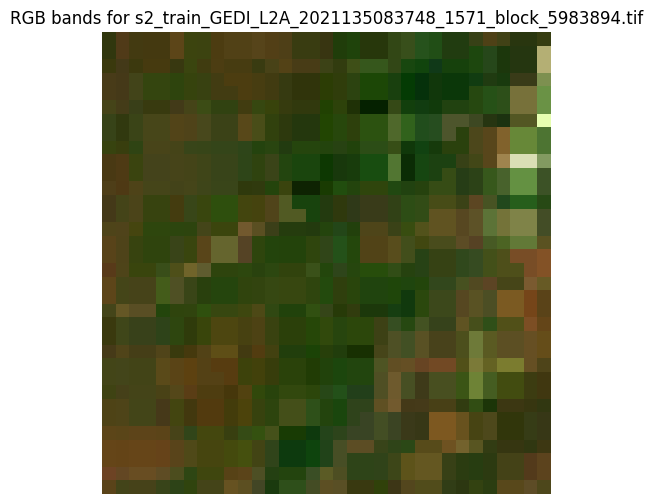


FILE: s2_val_GEDI_L2A_2022358084911_1259_block_5973892.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.029017647728323936
      max:  0.1599910706281662
      mean: 0.059280425486307936
      std:  0.016167635913515634

  Band 2 statistics:
      min:  0.03766363486647606
      max:  0.13379999995231628
      mean: 0.05729508660973158
      std:  0.012743836753831823

  Band 3 statistics:
      min:  0.026112500578165054
      max:  0.12184999883174896
      mean: 0.04014879845158018
      std:  0.010880725992075024

  Band 4 statistics:
      min:  0.1690666675567627
      max:  0.41705000400543213
      mean: 0.26552162495252735
      std:  0.036441957264015175

  Band 5 statistics:
      min:  0.12314999848604202
      max:  0.33572500944137573
      mean: 0.21912373929422202
      std:  0.030867000247056752

  Band 6 statistics:
      min:  0.07289999723434448
      max:  0.2919333279132843


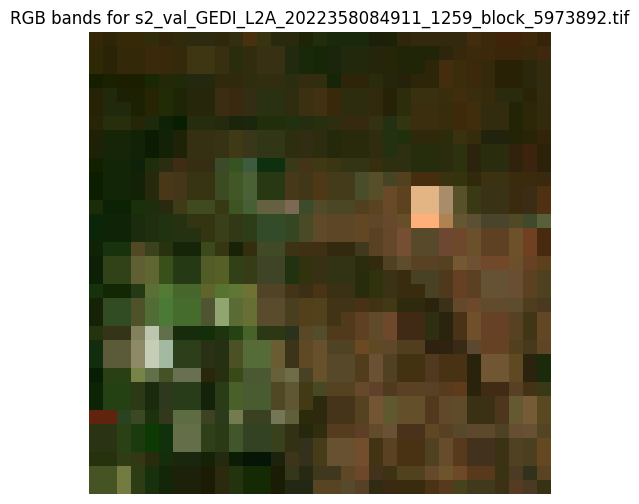


FILE: landsatidx_train_GEDI_L2A_2022358084911_820_block_5993895.tif
BANDS: 7
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.28705549240112305
      max:  0.8604122400283813
      mean: 0.7219859043373987
      std:  0.08313444259914356

  Band 2 statistics:
      min:  -0.7738508582115173
      max:  -0.35013091564178467
      mean: -0.6705902651212323
      std:  0.058770814402184984

  Band 3 statistics:
      min:  -0.6585548520088196
      max:  -0.3690888285636902
      mean: -0.5767925538197912
      std:  0.042574940275877715

  Band 4 statistics:
      min:  0.19164112210273743
      max:  0.5366814136505127
      mean: 0.38699362630193884
      std:  0.0600781789120916

  Band 5 statistics:
      min:  -0.15512360632419586
      max:  0.39596396684646606
      mean: 0.1564429454722239
      std:  0.08229224754958327

  Band 6 statistics:
      min:  -0.39596396684646606
      max:  0.15512360632419

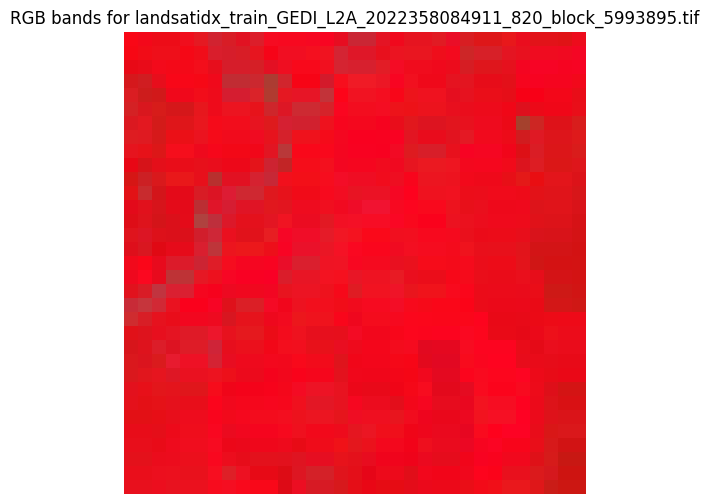


FILE: hls_train_GEDI_L2A_2022358084911_1276_block_5983893.tif
BANDS: 7
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.5005053281784058
      max:  0.8103241324424744
      mean: 0.6960247060484137
      std:  0.04039805041989996

  Band 2 statistics:
      min:  -0.762687623500824
      max:  -0.5214274525642395
      mean: -0.6715927157410796
      std:  0.04240453018010912

  Band 3 statistics:
      min:  -0.6944581270217896
      max:  -0.48771345615386963
      mean: -0.6051076257360212
      std:  0.033030981212450815

  Band 4 statistics:
      min:  0.160086989402771
      max:  0.5180131196975708
      mean: 0.3671796499068196
      std:  0.057849025006385876

  Band 5 statistics:
      min:  -0.07974163442850113
      max:  0.31454595923423767
      mean: 0.11364714451363989
      std:  0.06868432030333085

  Band 6 statistics:
      min:  -0.31454595923423767
      max:  0.07974163442850113
     

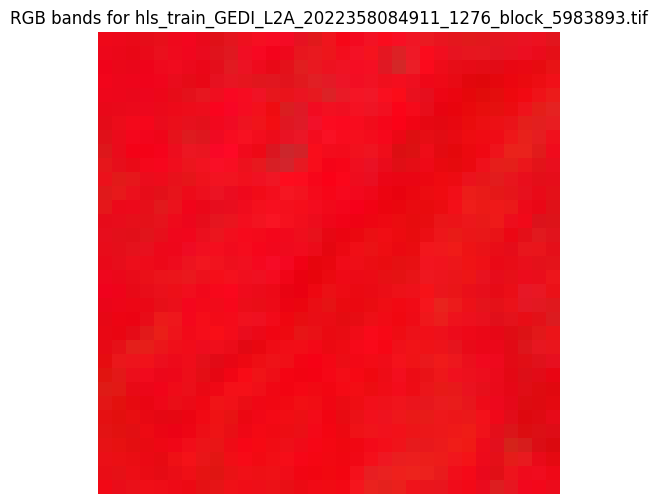


FILE: tcap_train_GEDI_L2A_2022358084911_1296_block_6003895.tif
BANDS: 6
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.07393082976341248
      max:  0.5726308822631836
      mean: 0.29538581853005336
      std:  0.04441282850802175

  Band 2 statistics:
      min:  -0.04667263850569725
      max:  0.14592963457107544
      mean: 0.07402298006126591
      std:  0.025983695523588164

  Band 3 statistics:
      min:  -0.15614695847034454
      max:  0.0369018130004406
      mean: -0.03020381132857094
      std:  0.02060336905720104

  Band 4 statistics:
      min:  -0.05941550061106682
      max:  -0.03392628952860832
      mean: -0.04535032985416538
      std:  0.002771650057532527

  Band 5 statistics:
      min:  -0.01909344270825386
      max:  0.09285102039575577
      mean: 0.008071750196723184
      std:  0.009430201031947784

  Band 6 statistics:
      min:  -0.03984382376074791
      max:  -0.01116534

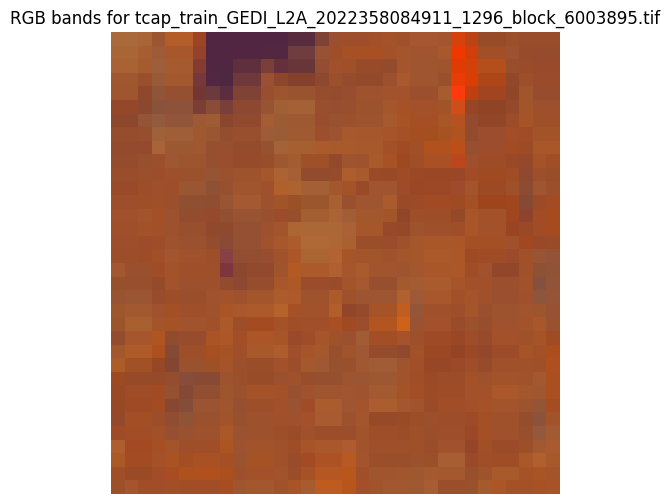

In [119]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files:
    fpath = os.path.join(RASTER_DIR, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {transform.e*-1} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b)
            data = data.astype(float)  # ensure numeric

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            band_min = np.nanmin(data)
            band_max = np.nanmax(data)
            band_mean = np.nanmean(data)
            band_std = np.nanstd(data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {band_min}")
            print(f"      max:  {band_max}")
            print(f"      mean: {band_mean}")
            print(f"      std:  {band_std}")

        # --- Visualization ---
        plt.figure(figsize=(6, 6))
        if count >= 3:
            # Read the first three bands for RGB visualization
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display (min-max)
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)
            plt.imshow(img)
            plt.title(f"RGB bands for {fname}")
        elif count == 1:
            # Read the single band for grayscale visualization
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Grayscale band for {fname}")
        else:
            print(f"Skipping visualization for {fname}: not enough bands for RGB or single band.")

        plt.axis('off')
        plt.show()

## Prep tifs: Pad, Normalize, inspect, save to content

In [120]:
from rasterio.enums import Resampling

def resize_to_max32(src):
    """
    Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
    Returns: resized array (bands, new_h, new_w) and updated transform
    """
    h = src.height
    w = src.width
    bands = src.count

    # No resizing needed
    if h <= 32 and w <= 32:
        return src.read(), src.transform

    scale_h = 32 / h
    scale_w = 32 / w
    scale = min(scale_h, scale_w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    resized = src.read(
        out_shape=(bands, new_h, new_w),
        resampling=Resampling.bilinear
    )

    # Update transform to match resized array
    new_transform = Affine(
        src.transform.a / scale, src.transform.b, src.transform.c,
        src.transform.d, src.transform.e / scale, src.transform.f
    )

    return resized, new_transform


# this block drops the spatial meta data updated above here on 11/25
# def resize_to_max32(src):
#     """
#     Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
#     Returns a numpy array (bands, new_h, new_w).
#     """
#     h = src.height
#     w = src.width
#     bands = src.count

#     # No resizing needed
#     if h <= 32 and w <= 32:
#         return src.read()

#     scale_h = 32 / h
#     scale_w = 32 / w
#     scale = min(scale_h, scale_w)

#     new_h = max(1, int(h * scale))
#     new_w = max(1, int(w * scale))

#     resized = src.read(
#         out_shape=(bands, new_h, new_w),
#         resampling=Resampling.bilinear
#     )

#     return resized


In [121]:
import numpy as np

def pad_to_32x32(arr, transform):
    """Center-pad a raster to exactly (bands, 32, 32) and adjust transform."""
    bands, h, w = arr.shape
    padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

    h_start = (32 - h) // 2
    w_start = (32 - w) // 2

    padded[:, h_start:h_start+h, w_start:w_start+w] = arr

    # Adjust transform to account for padding
    new_transform = transform * Affine.translation(-w_start, -h_start)
    return padded, new_transform



# this block drops the spatial meta data updated above here on 11/25
# def pad_to_32x32(arr):
#     """Center-pad a raster to exactly (bands, 32, 32)."""
#     bands, h, w = arr.shape
#     padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

#     h_start = (32 - h) // 2
#     w_start = (32 - w) // 2

#     padded[:, h_start:h_start+h, w_start:w_start+w] = arr
#     return padded


In [122]:
def minmax_normalize(arr):
    arr = arr.astype(float)
    for b in range(arr.shape[0]):
        mn = np.nanmin(arr[b])
        mx = np.nanmax(arr[b])
        arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
    return arr


In [123]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# -------------------------------------------------------------------------

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Scanning directory:", PROCESSED_DIR)

all_tifs = [
    f for f in os.listdir(PROCESSED_DIR)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0
dropped_files = 0

print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

selected_files = []   # <-- Files that pass checks
dropped_list = []     # <-- Files to delete


for fname in all_tifs:
    fpath = os.path.join(PROCESSED_DIR, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False
        too_many_nans = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True
            if nan_count >= 100:
                too_many_nans = True

            bands.append(data)

    # Drop files with too many NaNs
    if too_many_nans:
        dropped_files += 1
        dropped_list.append(fname)     # <--- NOW correctly recorded
        print(f"DROPPED: {fname} (≥100 NaNs)")
        continue

    # Fix files that have ≤99 NaNs
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                med = np.nanmedian(data)
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep this TIFF for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

print("Dropped files:", dropped_list)

# -------------------------------------------------------------------------
# DELETE DROPPED FILES
# -------------------------------------------------------------------------
print("\nDeleting dropped TIFF files...\n")

for fname in dropped_list:
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        os.remove(fpath)
        print("Deleted:", fname)

print("\nFinished deleting dropped TIFFs.")
print("Total deleted files:", len(dropped_list))


Scanning directory: /content/processed_32x32_normalized

Found 2414 TIFFs in /content/processed_32x32_normalized

DROPPED: s1_test_GEDI_L2A_2022139064237_194_block_5923889.tif (≥100 NaNs)
DROPPED: hls_train_GEDI_L2A_2022358084911_1867_block_6033897.tif (≥100 NaNs)
FIXING: hls_train_GEDI_L2A_2021135083748_118_block_5993896.tif (median fill)
DROPPED: landsatidx_train_GEDI_L2A_2021135083748_1176_block_6033889.tif (≥100 NaNs)
DROPPED: landsat_test_GEDI_L2A_2022139064237_228_block_5933887.tif (≥100 NaNs)
FIXING: tcap_train_GEDI_L2A_2022139064237_695_block_5923888.tif (median fill)
FIXING: hls_train_GEDI_L2A_2021135083748_624_block_6003893.tif (median fill)
DROPPED: tcap_train_GEDI_L2A_2022358084911_713_block_5923888.tif (≥100 NaNs)
FIXING: hls_train_GEDI_L2A_2021135083748_1609_block_6013891.tif (median fill)
FIXING: hls_test_GEDI_L2A_2021135083748_632_block_6013893.tif (median fill)
DROPPED: landsatidx_train_GEDI_L2A_2020196021509_1368_block_5913894.tif (≥100 NaNs)
DROPPED: hls_train_GEDI_L

In [125]:
import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling
import numpy as np
import os


processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(PROCESSED_DIR, fname)
    out_path = os.path.join(PROCESSED_DIR, fname)   # overwrite or change if desired


    with rasterio.open(src_path) as src:
        # Step 1: Resize
        resized, transform_resized = resize_to_max32(src)

        # Step 2: Pad
        padded, transform_padded = pad_to_32x32(resized, transform_resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile.copy()
        profile.update({
            "height": 32,
            "width": 32,
            "transform": transform_padded,
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

# this block drops the spatial meta data updated above here on 11/25
    # with rasterio.open(src_path) as src:

    #     # Step 1: Resize
    #     resized = resize_to_max32(src)

    #     # Step 2: Pad
    #     padded = pad_to_32x32(resized)

    #     # Step 3: Normalize
    #     normalized = minmax_normalize(padded)

    #     # Write raster
    #     profile = src.profile
    #     profile.update({
    #         "height": 32,
    #         "width": 32,
    #         "transform": rasterio.transform.from_origin(0, 0, 1, 1),
    #         "dtype": "float32"
    #     })

    #     with rasterio.open(out_path, "w", **profile) as dst:
    #         dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")


Processed 2186 TIFFs successfully.


## Compare before preprocessing

In [126]:
processed_sample_files = {}

for fname in sample_files:
    processed_path = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(processed_path):
        processed_sample_files[fname] = processed_path
    else:
        print(f"⚠️ WARNING: Processed version not found for {fname}")



PROCESSED FILE: s2_train_GEDI_L2A_2021135083748_1571_block_5983894.tif
LOCATION: /content/processed_32x32_normalized/s2_train_GEDI_L2A_2021135083748_1571_block_5983894.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 21.25 x 21.25 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5357477419020142
      std:  0.13784728009596875

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5251064138719812
      std:  0.11065348681421926

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.46363104844931513
      std:  0.10556172737217782

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.705126472923439
      std:  0.14215435502779417

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7659071140806191
      std:  0.15645700749844949

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5959199435310438
      std:  0.1376161614773333


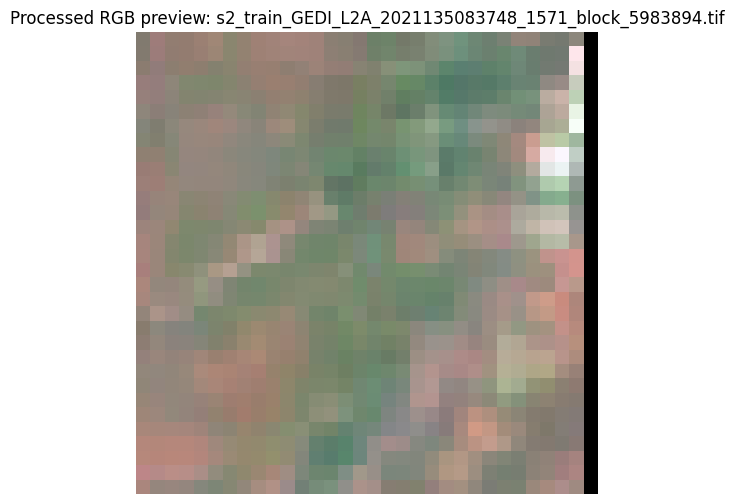


PROCESSED FILE: s2_val_GEDI_L2A_2022358084911_1259_block_5973892.tif
LOCATION: /content/processed_32x32_normalized/s2_val_GEDI_L2A_2022358084911_1259_block_5973892.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 20.625 x 20.625 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.2297860574661854
      std:  0.12335806322851077

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.1872035891192354
      std:  0.12499315446549197

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.14703859782957807
      std:  0.10430606679668454

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.38506926302579814
      std:  0.13756569386075218

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.43111360586772207
      std:  0.14171876933972002

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.20006312801359627
      std:  0.14045036426389848


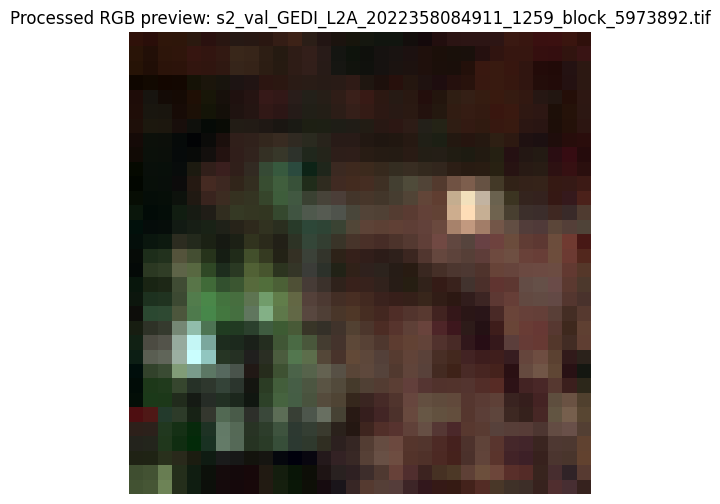


PROCESSED FILE: landsatidx_train_GEDI_L2A_2022358084911_820_block_5993895.tif
LOCATION: /content/processed_32x32_normalized/landsatidx_train_GEDI_L2A_2022358084911_820_block_5993895.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7022381015867722
      std:  0.1678064041072076

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.28507490704910765
      std:  0.15609083167392598

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.33604874217053293
      std:  0.1537121534820729

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5003119696593785
      std:  0.18671759484913492

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5379836385509407
      std:  0.17237754593582566

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.46201635834904664
      std:  0.17237754687532927

  Band 7

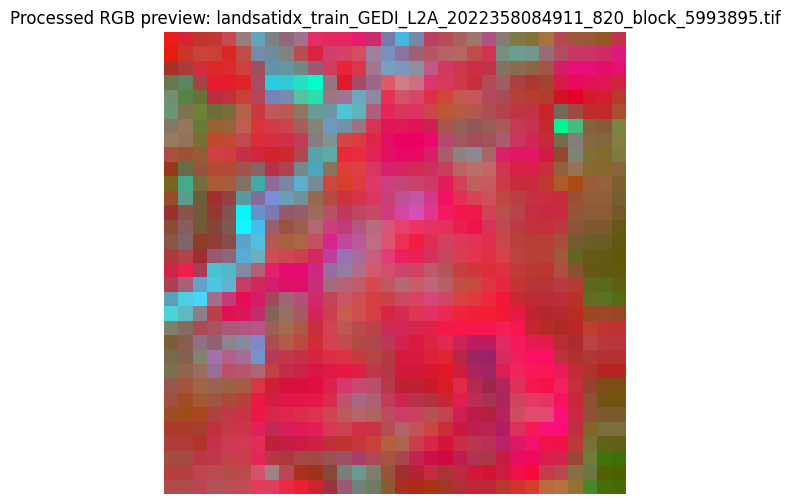


PROCESSED FILE: hls_train_GEDI_L2A_2022358084911_1276_block_5983893.tif
LOCATION: /content/processed_32x32_normalized/hls_train_GEDI_L2A_2022358084911_1276_block_5983893.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.9375 x 30.9375 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6312954110035207
      std:  0.14349166842037836

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.37557878795325905
      std:  0.18664991113223847

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4561899629507593
      std:  0.16221358868733127

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.618743924980663
      std:  0.16939798737199482

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.512039177625411
      std:  0.18832318567148193

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.48796082020029985
      std:  0.18832318616896035

  Band 7 statistics:


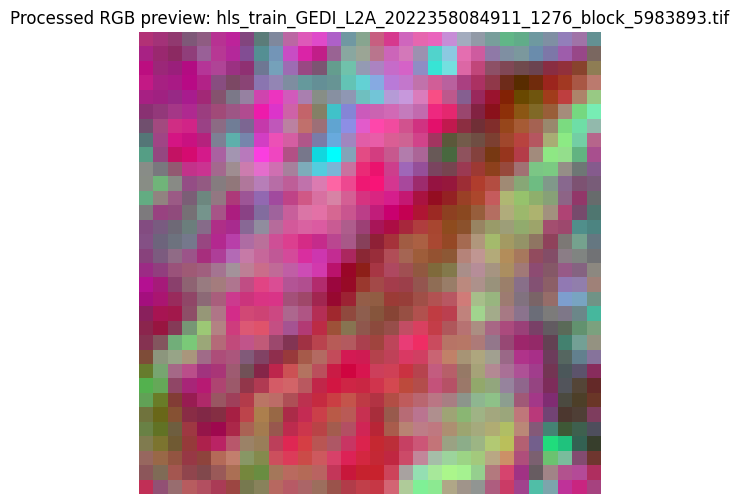


PROCESSED FILE: tcap_train_GEDI_L2A_2022358084911_1296_block_6003895.tif
LOCATION: /content/processed_32x32_normalized/tcap_train_GEDI_L2A_2022358084911_1296_block_6003895.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 31.875 x 31.875 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5925149418326328
      std:  0.1347377463304853

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6168954832976397
      std:  0.13899963957853204

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6220491735615497
      std:  0.10945160240050032

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.21399541733080696
      std:  0.1477908570238172

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3090920696959074
      std:  0.09427715623535282

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.36752810568577843
      std:  0.13146448137019048


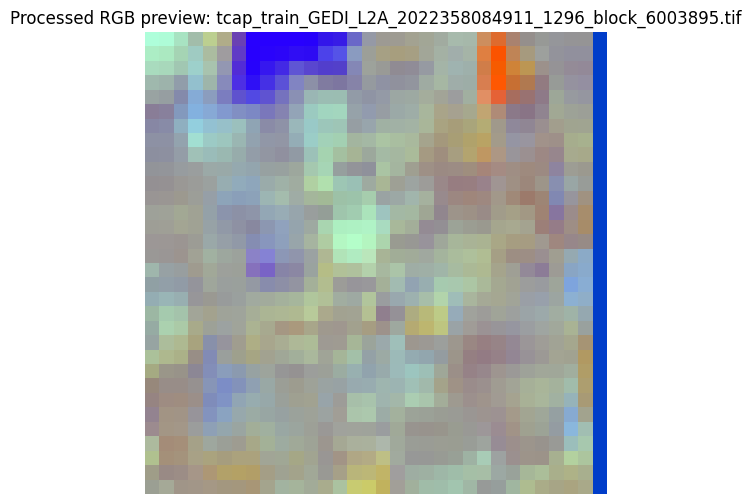

In [127]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (arbitrary)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


## Target filter

In [128]:
import pandas as pd

GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# Load CSV
df = pd.read_csv(GEDI_CSV)

# Filter for product_field == "GEDI_LSA"
df_filtered_GEDI_L2A = df[df["product_field"] == "GEDI_L2A"]

df_filtered_GEDI_L2A


/tmp/ipython-input-686974334.py:6: DtypeWarning:

Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.



,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1863,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217155,-85.859947,549.746216,567.769958,-41.230606,0.977462,0.0,1.0,...,NaN,NaN,NaN,603758.425670,3.897721e+06,603,3897,603_3897,1864,train
1864,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217505,-85.859484,550.669312,566.905273,-41.230209,0.975680,0.0,1.0,...,NaN,NaN,NaN,603800.146408,3.897760e+06,603,3897,603_3897,1865,train
1865,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217854,-85.859021,549.173706,566.905273,-41.229813,0.978489,0.0,1.0,...,NaN,NaN,NaN,603841.799971,3.897799e+06,603,3897,603_3897,1866,train
1866,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,NaN,NaN,NaN,603925.187830,3.897878e+06,603,3897,603_3897,1867,train


### Pair Tif and GEDI Obs (Targets)

In [129]:
import re

FILENAME_RE = re.compile(
    r"^(?P<cov>[a-zA-Z0-9]+)_"          # covariate (s1, s2, landsatidx, etc)
    r"(?P<split>train|test|val)_"       # split
    r"GEDI_L2A_"                        # product field (constant)
    r"(?P<shot>\d+)_"                   # shot
    r"(?P<row_ID>\d+)_"                 # row_ID
    r"block_(?P<block_id>\d+)\.tif$"    # block_id
)


In [130]:
import os
import pandas as pd

TIFF_ROOT = "/content/processed_32x32_normalized"

rows = []

for fn in os.listdir(TIFF_ROOT):
    if not fn.endswith(".tif"):
        continue

    m = FILENAME_RE.match(fn)
    if m is None:
        print("WARNING: filename did not match pattern:", fn)
        continue

    d = m.groupdict()
    d["filename"] = fn
    d["full_path"] = os.path.join(TIFF_ROOT, fn)
    rows.append(d)

tif_df = pd.DataFrame(rows)
print("Parsed TIFFs:", len(tif_df))
print(tif_df.head())


Parsed TIFFs: 2186
          cov  split           shot row_ID block_id  \
0          s2  train  2021135083748   1525  5953896   
1         hls  train  2022358084911   1197  5923888   
2          s1   test  2022358084911    867  6013897   
3     landsat  train  2022358084911    771  5963892   
4  landsatidx  train  2021135083748    524  5963897   

                                            filename  \
0  s2_train_GEDI_L2A_2021135083748_1525_block_595...   
1  hls_train_GEDI_L2A_2022358084911_1197_block_59...   
2  s1_test_GEDI_L2A_2022358084911_867_block_60138...   
3  landsat_train_GEDI_L2A_2022358084911_771_block...   
4  landsatidx_train_GEDI_L2A_2021135083748_524_bl...   

                                           full_path  
0  /content/processed_32x32_normalized/s2_train_G...  
1  /content/processed_32x32_normalized/hls_train_...  
2  /content/processed_32x32_normalized/s1_test_GE...  
3  /content/processed_32x32_normalized/landsat_tr...  
4  /content/processed_32x32_normalized

In [131]:
print("\nTIFF counts per covariate:")
print(tif_df["cov"].value_counts())



TIFF counts per covariate:
cov
s2            514
landsat       260
dem           260
landsatidx    260
tcap          260
hls           258
s1            237
s2idx         137
Name: count, dtype: int64


In [132]:
df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)
tif_df["row_ID"] = tif_df["row_ID"].astype(int)

merged = df_filtered_GEDI_L2A.merge(tif_df, on="row_ID", how="left")


/tmp/ipython-input-1886280410.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [133]:
valid = merged[~merged["filename"].isna()]
print("GEDI L2A rows:", len(df_filtered_GEDI_L2A))
print("Rows with matching TIFFs:", len(valid["row_ID"].unique()))


GEDI L2A rows: 1868
Rows with matching TIFFs: 663


In [134]:
df_valid = pd.DataFrame(valid)

In [135]:
df_valid

,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,block_y,block_id_x,row_ID,split_x,cov,split_y,shot,block_id_y,filename,full_path
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,s1,val,2020196021509,5923897,s1_val_GEDI_L2A_2020196021509_4_block_5923897.tif,/content/processed_32x32_normalized/s1_val_GED...
6,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.217882,-85.984680,504.926117,517.720337,-18.850962,0.976463,0.0,1.0,...,3897,592_3897,7,val,s2,val,2020196021509,5923897,s2_val_GEDI_L2A_2020196021509_7_block_5923897.tif,/content/processed_32x32_normalized/s2_val_GED...
10,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.219275,-85.982846,511.952362,524.200256,-18.851089,0.974180,0.0,1.0,...,3897,592_3897,11,val,s2,val,2020196021509,5923897,s2_val_GEDI_L2A_2020196021509_11_block_5923897...,/content/processed_32x32_normalized/s2_val_GED...
11,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.219631,-85.982373,499.648376,505.862122,-18.851122,0.990057,0.0,1.0,...,3897,592_3897,12,val,tcap,val,2020196021509,5923897,tcap_val_GEDI_L2A_2020196021509_12_block_59238...,/content/processed_32x32_normalized/tcap_val_G...
12,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.219631,-85.982373,499.648376,505.862122,-18.851122,0.990057,0.0,1.0,...,3897,592_3897,12,val,landsat,val,2020196021509,5923897,landsat_val_GEDI_L2A_2020196021509_12_block_59...,/content/processed_32x32_normalized/landsat_va...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.213315,-85.865033,555.326599,574.336975,-41.234959,0.968937,0.0,1.0,...,3897,603_3897,1853,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1853_block_603...,/content/processed_32x32_normalized/s2_train_G...
3377,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.214012,-85.864110,555.053955,566.020325,-41.234169,0.970757,0.0,1.0,...,3897,603_3897,1855,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1855_block_603...,/content/processed_32x32_normalized/s2_train_G...
3380,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.215059,-85.862724,550.813904,554.111755,-41.232986,0.973757,0.0,1.0,...,3897,603_3897,1858,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1858_block_603...,/content/processed_32x32_normalized/s2_train_G...
3383,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.216107,-85.861335,552.883972,555.467957,-41.231796,0.979334,0.0,1.0,...,3897,603_3897,1861,train,s2,train,2022358084911,6033897,s2_train_GEDI_L2A_2022358084911_1861_block_603...,/content/processed_32x32_normalized/s2_train_G...


In [136]:
count_co = (df_valid['row_ID'] == 'cov').sum()
print(f"The number of entries matching 'cov' is: {count_co}")


The number of entries matching 'cov' is: 0


In [ ]:
# df_valid.to_csv('df_valid.csv', index=False)

In [137]:
column_names = valid.columns.tolist()
print(column_names)

['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin_0', 'pgap_theta',

In [138]:
eo_list = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

print("\nCounts per EO by split:")
for eo in eo_list:
    eo_df = tif_df[tif_df["cov"] == eo]
    print(f"\nEO = {eo}")
    print(eo_df["split"].value_counts())



Counts per EO by split:

EO = s1
split
train    165
test      48
val       24
Name: count, dtype: int64

EO = s2
split
train    371
test      92
val       51
Name: count, dtype: int64

EO = landsat
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = landsatidx
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = hls
split
train    192
test      42
val       24
Name: count, dtype: int64

EO = tcap
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = dem
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = s2idx
split
train    104
test      22
val       11
Name: count, dtype: int64


## Data loaders

In [139]:
EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
SPATIAL_RES = {
    's1': 10, 's2': 20, 's2idx': 20,
    'landsat': 30, 'landsatidx': 30,
    'hls': 30, 'tcap': 30, 'dem': 30
}
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

In [140]:
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import random


# -----------------------
# Remove NaN samples
# -----------------------
def drop_nan_samples(df):
    clean_rows = []
    dropped = 0

    for i, row in df.iterrows():
        fp = row["full_path"]
        try:
            with rasterio.open(fp) as src:
                arr = src.read().astype(np.float32)
                if np.isnan(arr).any():
                    dropped += 1
                    continue
        except:
            dropped += 1
            continue

        clean_rows.append(row)

    clean_df = pd.DataFrame(clean_rows).reset_index(drop=True)
    print(f"\n[CLEAN] Removed {dropped} NaN samples. Remaining: {len(clean_df)}")
    return clean_df

# -----------------------
# Dataset for a single EO
# -----------------------
class GeoTiffDataset(Dataset):
    def __init__(self, df, eo, bands_per_cov, target_col='rh', transform=None, augment=False, split='train'):
        """
        Single-EO Dataset for multibranch model.
        df: pandas DataFrame
        eo: EO type (string, must match 'cov' column)
        bands_per_cov: dict mapping EO type to number of bands
        target_col: target column name
        transform: optional transform
        augment: whether to apply flips and rotations
        split: data partition ('train', 'val', 'test')
        """
        # Filter rows by EO and split
        self.df = df[(df['cov'] == eo) & (df['split_x'] == split)].reset_index(drop=True)
        self.eo = eo
        self.bands = bands_per_cov[eo]
        self.target_col = target_col
        self.transform = transform
        self.augment = augment

        if len(self.df) == 0:
            print(f"[WARNING] Dataset for EO '{eo}' and split '{split}' initialized with 0 samples!")
        else:
            print(f"[INFO] Dataset for EO '{eo}' and split '{split}' initialized with {len(self.df)} samples")
        print(f"[INFO] Target column: {self.target_col}")
        print(f"[INFO] Augmentation enabled: {self.augment}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row['full_path']

        with rasterio.open(fp) as src:
            arr = src.read().astype(np.float32)  # (C, H, W)

        # Verify band count
        if arr.shape[0] != self.bands:
            raise ValueError(f"EO {self.eo} at idx {idx} has {arr.shape[0]} bands, expected {self.bands}")

        # Augmentation: flips and rotations
        if self.augment:
            if random.random() > 0.5:  # horizontal flip
                arr = arr[:, :, ::-1].copy()
            if random.random() > 0.5:  # vertical flip
                arr = arr[:, ::-1, :].copy()
            k = random.randint(0, 3)
            arr = np.rot90(arr, k, axes=(1, 2)).copy()

        if self.transform:
            arr = self.transform(arr)

        x = torch.tensor(arr, dtype=torch.float32)
        y = torch.tensor(row[self.target_col], dtype=torch.float32)

        # return x, y
        return {
        "image": x,      #
        "target": y,     #
        "path": fp       # 11/20 !!!! NEW — adds full file path for embedding fusion
    }

# -----------------------
# Function to create loaders per EO and split
# -----------------------
def create_multibranch_loaders(df, eo_list, bands_per_cov, target_col='rh', batch_size=16, augment=False, split='train'):
    """
    Create a dictionary of DataLoaders per EO.
    Returns: dict {eo: DataLoader}
    """
    loaders = {}
    for eo in eo_list:
        dataset = GeoTiffDataset(df, eo, bands_per_cov, target_col=target_col, augment=augment, split=split)
        if len(dataset) == 0:
            print(f"[WARNING] Skipping EO '{eo}' because dataset is empty for split '{split}'")
            continue
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=(split=='train'), num_workers=2)
        loaders[eo] = loader
        print(f"[INFO] DataLoader for EO '{eo}' created with {len(loader)} batches, batch size {batch_size}")
    return loaders

# -----------------------
# Example usage: create loaders for all EO branches for 'train' split
# -----------------------
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

train_loaders = create_multibranch_loaders(valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=True, split='train')

# # -----------------------
# # Inspect first batch per EO
# # -----------------------
# for eo, loader in train_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)

#     # -----------------------
# Inspect first batch per EO
# -----------------------
for eo, loader in train_loaders.items():

    batch = next(iter(loader))     # 11/20 fix ⭐ one dict now, not two tensors

    print(f"\n[INFO] EO branch: {eo}")
    print(f"  Image batch shape:  {batch['image'].shape}")   # (B, C, H, W)
    print(f"  Target batch shape: {batch['target'].shape}")  # (B,)
    print(f"  Example path:       {batch['path'][0]}")        # first file path



[INFO] Dataset for EO 's1' and split 'train' initialized with 165 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's1' created with 11 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'train' initialized with 371 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's2' created with 24 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'train' initialized with 194 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsat' created with 13 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'train' initialized with 194 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsatidx' created with 13 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'train' initialized with 192 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'hls' c

In [141]:
# -----------------------
# Test loaders without augmentation
# -----------------------
test_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='test'
)

# -----------------------
# Inspect first batch per EO for TEST
# -----------------------
print("\n==================== TEST LOADERS ====================")
# for eo, loader in test_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] Split: TEST | EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)
##11/20 fix
for eo, loader in test_loaders.items():
    batch = next(iter(loader))             # <-- CHANGED: now batch is a dict
    imgs   = batch["image"]                # <-- CHANGED
    tgts   = batch["target"]               # <-- CHANGED
    paths  = batch["path"]                 # <-- CHANGED: list of file paths

    print(f"\n[INFO] Split: TEST | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")     # (B, C, H, W)
    print(f"  Target batch shape: {tgts.shape}")     # (B,)
    print(f"  Example path:       {paths[0]}")       # path string



# -----------------------
# Validation loaders without augmentation
# -----------------------
val_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='val'
)

# -----------------------
# Inspect first batch per EO for VAL
# -----------------------
# print("\n==================== VAL LOADERS ====================")
# for eo, loader in val_loaders.items():
#     first_sample, first_target = next(iter(loader))
#     print(f"\n[INFO] Split: VAL | EO branch: {eo}")
#     print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
#     print(f"  Target shape: {first_target.shape}")  # (B,)'

#11/20 fix
print("\n==================== VAL LOADERS ====================")

for eo, loader in val_loaders.items():
    batch = next(iter(loader))             # <-- CHANGED
    imgs   = batch["image"]                # <-- CHANGED
    tgts   = batch["target"]               # <-- CHANGED
    paths  = batch["path"]                 # <-- CHANGED

    print(f"\n[INFO] Split: VAL | EO branch: {eo}")
    print(f"  Image batch shape:  {imgs.shape}")
    print(f"  Target batch shape: {tgts.shape}")
    print(f"  Example path:       {paths[0]}")


[INFO] Dataset for EO 's1' and split 'test' initialized with 48 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's1' created with 3 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'test' initialized with 92 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's2' created with 6 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'test' initialized with 42 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsat' created with 3 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'test' initialized with 42 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsatidx' created with 3 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'test' initialized with 42 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'hls' created wi

### check for NAN

In [142]:
# -----------------------
# Check datasets + loaders for NaN values
# -----------------------

def check_nans_in_dataset(df, eo_list):
    print("\n========== DATASET NaN CHECK ==========")
    import rasterio
    import numpy as np

    for eo in eo_list:
        subdf = df[df["cov"] == eo]
        if len(subdf) == 0:
            print(f"[INFO] EO '{eo}' has no rows in dataframe.")
            continue

        nan_files = []
        for _, row in subdf.iterrows():
            fp = row["full_path"]
            try:
                with rasterio.open(fp) as src:
                    arr = src.read().astype(np.float32)
                    if np.isnan(arr).any():
                        nan_files.append(fp)
            except Exception as e:
                print(f"[ERROR] Could not read {fp}: {e}")

        if len(nan_files) > 0:
            print(f"[WARNING] EO '{eo}' has {len(nan_files)} files containing NaN.")
            for f in nan_files[:5]:  # show first 5
                print("    ", f)
        else:
            print(f"[OK] EO '{eo}' has no NaN values in any raster.")

##11/20 ddrsssing dictdictionary  to three elemtns
def check_nans_in_loaders(loaders):
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders.items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        # Handle dict batches
        if isinstance(batch, dict):
            batch_x = batch.get("image")
            batch_y = batch.get("target")
        else:
            # fallback for tuple/list batches
            batch_x, batch_y = batch

        x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
        y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")


##11/17
# def check_nans_in_loaders(loaders):
#     print("\n========== LOADER NaN CHECK ==========")
#     import torch

#     for eo, loader in loaders.items():
#         try:
#             batch_x, batch_y = next(iter(loader))
#         except StopIteration:
#             print(f"[WARNING] EO '{eo}' loader is empty.")
#             continue

#         x_nan = torch.isnan(batch_x).any().item()
#         y_nan = torch.isnan(batch_y).any().item()

#         if x_nan or y_nan:
#             print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
#             print(f"   NaN in inputs: {x_nan}")
#             print(f"   NaN in targets: {y_nan}")
#         else:
#             print(f"[OK] EO '{eo}' first batch has no NaNs.")

# ---------- RUN CHECKS ----------
check_nans_in_dataset(valid, EO_LIST)
check_nans_in_loaders(train_loaders)



========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.


In [143]:
###11/20 addressing dictionary to return three elements
# -----------------------
# Run NaN checks across all splits
# -----------------------
splits = ['train', 'val', 'test']
loaders_dict = {
    'train': train_loaders,
    'val': val_loaders,
    'test': test_loaders
}

for split in splits:
    print(f"\n==================== NaN CHECK: {split.upper()} ====================")

    # Check dataset
    check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

    # Check loaders
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders_dict[split].items():
        try:
            batch = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        # Handle dict batches
        if isinstance(batch, dict):
            batch_x = batch.get("image")
            batch_y = batch.get("target")
        else:
            # fallback for tuple/list batches
            batch_x, batch_y = batch

        x_nan = torch.isnan(batch_x).any().item() if batch_x is not None else False
        y_nan = torch.isnan(batch_y).any().item() if batch_y is not None else False

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")



#11/17
# # -----------------------
# # Run NaN checks across all splits
# # -----------------------
# splits = ['train', 'val', 'test']
# loaders_dict = {
#     'train': train_loaders,
#     'val': val_loaders,
#     'test': test_loaders
# }

# for split in splits:
#     print(f"\n==================== NaN CHECK: {split.upper()} ====================")

#     # Check dataset
#     check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

#     # Check loaders
#     check_nans_in_loaders(loaders_dict[split])



==================== NaN CHECK: TRAIN ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.

==================== NaN CHECK: VAL ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[O

## GEDI L1B Autoendcoder and dataset and loader construction

In [144]:
import numpy as np

file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'

# Load with allow_pickle=True
arr = np.load(file_path, allow_pickle=True)

# Check if any NaN exists
# For object arrays, np.isnan might not work directly, so use a comprehension
has_nan = any(np.isnan(x) if isinstance(x, (int, float, np.number)) else False for x in arr.flatten())

print("Any NaN values?", has_nan)

# Count NaNs
num_nan = sum(1 for x in arr.flatten() if isinstance(x, (int, float, np.number)) and np.isnan(x))
print("Number of NaN values:", num_nan)


Any NaN values? False
Number of NaN values: 0


In [ ]:
# import numpy as np
# import torch
# from torch.utils.data import Dataset

# # 1️ Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
# data = np.load(file_path, allow_pickle=True).item()  # actual_data = data.item()

# # 2️ Inspect keys if it’s a dict
# print("Keys in the .npy object:", list(data.keys()))

# # Assuming the waveform data is under the key 'rxwaveform' (adjust if different)
# waveforms = data['rxwaveform']  # should be a list or array of arrays

# # 3️ Define a PyTorch Dataset
# class RxWaveformDataset(Dataset):
#     def __init__(self, waveforms, transform=None, fixed_length=None):
#         self.transform = transform
#         self.fixed_length = fixed_length
#         self.data = []

#         for wf in waveforms:
#             arr = np.array(wf, dtype=np.float32)

#             # Pad or truncate to fixed length if specified
#             if fixed_length is not None:
#                 if len(arr) < fixed_length:
#                     arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
#                 else:
#                     arr = arr[:fixed_length]

#             self.data.append(arr)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         waveform = self.data[idx]
#         if self.transform:
#             waveform = self.transform(waveform)
#         return torch.tensor(waveform, dtype=torch.float32)

# # 4️⃣ Create the dataset
# dataset_rx = RxWaveformDataset(waveforms, fixed_length=1024)  # adjust fixed_length if needed
# print("Number of waveforms:", len(dataset_rx))
# print("Shape of first waveform:", dataset_rx[0].shape)


In [ ]:

# ### 11/17 works great commented out so that i cna add a indexing for emdedding index later
# import numpy as np
# import torch
# from torch.utils.data import Dataset, DataLoader

# # 1️ Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
# data = np.load(file_path, allow_pickle=True).item()

# # 2️ Inspect keys
# print("Keys in the .npy object:", list(data.keys()))

# # Assuming waveform data is under 'rxwaveform'
# waveforms = data['rxwaveform']

# # 3️ Define PyTorch Dataset
# class RxWaveformDataset(Dataset):
#     def __init__(self, waveforms, transform=None, fixed_length=None):
#         self.transform = transform
#         self.fixed_length = fixed_length
#         self.data = []

#         for wf in waveforms:
#             arr = np.array(wf, dtype=np.float32)

#             # Pad or truncate to fixed length
#             if fixed_length is not None:
#                 if len(arr) < fixed_length:
#                     arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
#                 else:
#                     arr = arr[:fixed_length]

#             # Add channel dimension for CNN: (1, length)
#             arr = np.expand_dims(arr, axis=0)
#             self.data.append(arr)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         waveform = self.data[idx]
#         if self.transform:
#             waveform = self.transform(waveform)
#         return torch.tensor(waveform, dtype=torch.float32)

# # 4️ Create the dataset
# fixed_length = 1024
# dataset_rx = RxWaveformDataset(waveforms, fixed_length=fixed_length)
# print("Number of waveforms:", len(dataset_rx))
# print("Shape of first waveform:", dataset_rx[0].shape)  # should be (1, fixed_length)

# # 5️ Create a DataLoader
# batch_size = 8
# loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# # Check batch shapes
# # for batch in loader:
# #     print("Batch shape:", batch.shape)  # should be (batch_size, 1, fixed_length)
# #     break


In [145]:

### 11/20 added df_wave to keep track of position
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ---------------------------
# 1️⃣ Load the .npy file
# ---------------------------
file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
data = np.load(file_path, allow_pickle=True).item()

waveforms = data['rxwaveform']
num_samples = len(waveforms)

# Optional: extract targets or metadata if needed
# Example: we’ll just create dummy targets for now
# Replace 'targets' with your actual supervised target array
targets = np.zeros(num_samples, dtype=np.float32)

# ---------------------------
# 2️⃣ Build reference table
# ---------------------------
import pandas as pd

df_wave = pd.DataFrame({
    "sample_idx": np.arange(num_samples),  # acts as “file path” stand-in
    "target": targets
    # Add other metadata if desired, e.g., latitude_bin0, longitude_bin0, shot_number
})

# ---------------------------
# 3️⃣ Define PyTorch Dataset
# ---------------------------
class RxWaveformDataset(Dataset):
    def __init__(self, df, waveforms, fixed_length=1024, transform=None):
        self.df = df
        self.waveforms = waveforms
        self.fixed_length = fixed_length
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        wf = np.array(self.waveforms[idx], dtype=np.float32)

        # Pad or truncate
        if len(wf) < self.fixed_length:
            wf = np.pad(wf, (0, self.fixed_length - len(wf)), mode='constant')
        else:
            wf = wf[:self.fixed_length]

        # Add channel dimension for CNN: (1, length)
        wf = np.expand_dims(wf, axis=0)

        if self.transform:
            wf = self.transform(wf)

        x = torch.tensor(wf, dtype=torch.float32)
        y = torch.tensor(self.df.iloc[idx]["target"], dtype=torch.float32)
        ref = self.df.iloc[idx]["sample_idx"]  # acts like 'path'

        return {
            "image": x,     # waveform tensor
            "target": y,    # supervised label
            "path": ref     # unique sample index
        }

# ---------------------------
# 4️⃣ Create Dataset + DataLoader
# ---------------------------
fixed_length = 1024
dataset_rx = RxWaveformDataset(df_wave, waveforms, fixed_length=fixed_length)

batch_size = 8
loader_rx = DataLoader(dataset_rx, batch_size=batch_size, shuffle=True)

# ---------------------------
# 5️⃣ Verify
# ---------------------------
batch = next(iter(loader_rx))
print("Batch 'image' shape:", batch["image"].shape)   # (B, 1, 1024)
print("Batch 'target' shape:", batch["target"].shape) # (B,)
print("Batch 'path':", batch["path"])                 # sample indices


Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'path': tensor([1121., 3037., 2571., 1944.,  500., 1565., 3084.,  222.],
       dtype=torch.float64)


In [ ]:
#11.17 dropped for indexing

# # Assuming you already have your DataLoader
# loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# # Inspect a single batch
# for i, batch in enumerate(loader_rx):
#     print(f"Batch {i} type: {type(batch)}")
#     print(f"Batch {i} shape: {batch.shape}")  # should be (batch_size, 1, fixed_length)
#     print(f"Batch {i} dtype: {batch.dtype}")
#     print(f"Batch {i} first waveform sample:\n{batch[0]}")
#     break  # just show the first batch


Batch 0 type: <class 'torch.Tensor'>
Batch 0 shape: torch.Size([8, 1, 1024])
Batch 0 dtype: torch.float32
Batch 0 first waveform sample:
tensor([[206.6632, 207.0118, 206.9288,  ..., 211.8406, 210.9343, 209.7292]])


In [146]:
#11/20 added for indexing embedding
# Assuming you already have your DataLoader
loader_rx = DataLoader(dataset_rx, batch_size=8, shuffle=True)

# Inspect a single batch
for i, batch in enumerate(loader_rx):
    print(f"Batch {i} type: {type(batch)}")  # should be <class 'dict'>

    # Shapes
    print(f"Batch 'image' shape: {batch['image'].shape}")   # (batch_size, 1, fixed_length)
    print(f"Batch 'target' shape: {batch['target'].shape}") # (batch_size,)

    # Data types
    print(f"Batch 'image' dtype: {batch['image'].dtype}")
    print(f"Batch 'target' dtype: {batch['target'].dtype}")

    # Example first waveform
    print(f"Batch 'image' first waveform sample:\n{batch['image'][0]}")

    # Path/sample_idx
    print(f"Batch 'path' (sample indices): {batch['path']}")

    break  # just show the first batch


Batch 0 type: <class 'dict'>
Batch 'image' shape: torch.Size([8, 1, 1024])
Batch 'target' shape: torch.Size([8])
Batch 'image' dtype: torch.float32
Batch 'target' dtype: torch.float32
Batch 'image' first waveform sample:
tensor([[221.8981, 221.6388, 221.3273,  ...,   0.0000,   0.0000,   0.0000]])
Batch 'path' (sample indices): tensor([1953.,  610.,  871.,  179., 1289., 3432.,   63., 1251.],
       dtype=torch.float64)


# Stage 1 Modeling

## EO only

In [147]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchEmbed(nn.Module):
    """Converts image to patch embeddings."""
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, num_patches, embed_dim]
        x = self.proj(x)  # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [seq_len, B, embed_dim] for nn.MultiheadAttention
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTCustom(nn.Module):
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        # transformer expects [seq_len, B, embed_dim]
        x = x.transpose(0,1)
        for blk in self.blocks:
            x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        return x[:,0]  # return cls token embedding


In [ ]:
# def train_vit_branch(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")
#     return model


In [ ]:
# import matplotlib.pyplot as plt

# def train_vit_branch_with_plot(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     epoch_losses = []  # store average loss per epoch

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_loss = total_loss / len(loader)
#         epoch_losses.append(avg_loss)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

#     # Plot the loss curve
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), epoch_losses, marker='o')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training Loss Curve")
#     plt.grid(True)
#     plt.show()

#     return model


In [148]:
#11/20 version
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
    model = model.to(device)

    # -------------------------------------------------------------
    # 1) Build regression head ONCE using known embedding dimension
    # -------------------------------------------------------------
    batch = next(iter(train_loader))           # FIXED: dataset returns dict
    example_x = batch["image"].to(device)      # FIXED
    with torch.no_grad():
        example_emb = model(example_x)
    emb_dim = example_emb.shape[1]

    head = nn.Linear(emb_dim, 1).to(device)

    # -------------------------------------------------------------
    # 2) One optimizer for BOTH encoder + head
    # -------------------------------------------------------------
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(head.parameters()),
        lr=lr
    )
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # ---------------------
        # Training
        # ---------------------
        model.train()
        head.train()
        total_loss = 0

        for batch in train_loader:                    # FIXED: dict
            x = batch["image"].to(device)
            y = batch["target"].to(device).float()

            optimizer.zero_grad()
            emb = model(x)
            pred = head(emb)

            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---------------------
        # Test Evaluation
        # ---------------------
        model.eval()
        head.eval()
        total_test_loss = 0

        with torch.no_grad():
            for batch in test_loader:                 # FIXED: dict
                x_test = batch["image"].to(device)
                y_test = batch["target"].to(device).float()

                emb_test = model(x_test)
                pred_test = head(emb_test)

                loss_test = criterion(pred_test.squeeze(), y_test)
                total_test_loss += loss_test.item()

        avg_test_loss = total_test_loss / len(test_loader)
        print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
        test_losses.append(avg_test_loss)

    # ---------------------
    # Plot training & test loss
    # ---------------------
    plt.figure(figsize=(6,4))
    plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training & Test Loss Curve")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Return BOTH the encoder and the trained regression head
    return model, head






# #11/18 approach version work with no dicitonary dataeset loader (fill path additon )
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):

#     model = model.to(device)

#     # -------------------------------------------------------------
#     # 1) Build regression head ONCE using known embedding dimension
#     # -------------------------------------------------------------
#     # get one batch to infer embedding dimension
#     example_x, _ = next(iter(train_loader))
#     example_x = example_x.to(device)
#     with torch.no_grad():
#         example_emb = model(example_x)
#     emb_dim = example_emb.shape[1]

#     head = nn.Linear(emb_dim, 1).to(device)

#     # -------------------------------------------------------------
#     # 2) One optimizer for BOTH encoder + head
#     # -------------------------------------------------------------
#     optimizer = torch.optim.Adam(
#         list(model.parameters()) + list(head.parameters()),
#         lr=lr
#     )
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):

#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         head.train()
#         total_loss = 0

#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device).float()

#             optimizer.zero_grad()

#             emb = model(x)          # ViT embedding
#             pred = head(emb)        # persistent head

#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test Evaluation
#         # ---------------------
#         model.eval()
#         head.eval()
#         total_test_loss = 0

#         with torch.no_grad():
#             for x_test, y_test in test_loader:
#                 x_test, y_test = x_test.to(device), y_test.to(device).float()

#                 emb_test = model(x_test)
#                 pred_test = head(emb_test)

#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 total_test_loss += loss_test.item()

#         avg_test_loss = total_test_loss / len(test_loader)
#         test_losses.append(avg_test_loss)

#         print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     # Return BOTH the encoder and the trained regression head
#     return model, head



#11/17 approach
# import matplotlib.pyplot as plt
# import torch
# import torch.nn as nn

# def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     train_losses = []
#     test_losses = []

#     for epoch in range(epochs):
#         # ---------------------
#         # Training
#         # ---------------------
#         model.train()
#         total_loss = 0
#         for x, y in train_loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # linear head
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_train_loss = total_loss / len(train_loader)
#         train_losses.append(avg_train_loss)

#         # ---------------------
#         # Test loss (no grad)
#         # ---------------------
#         model.eval()
#         test_loss_total = 0
#         with torch.no_grad():
#             for x_test, y_test in test_loader:
#                 x_test, y_test = x_test.to(device), y_test.to(device).float()
#                 emb_test = model(x_test)
#                 pred_test = nn.Linear(emb_test.shape[1], 1).to(device)(emb_test)
#                 loss_test = criterion(pred_test.squeeze(), y_test)
#                 test_loss_total += loss_test.item()
#         avg_test_loss = test_loss_total / len(test_loader)
#         test_losses.append(avg_test_loss)

#         print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

#     # ---------------------
#     # Plot training & test loss
#     # ---------------------
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
#     plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training & Test Loss Curve")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

#     return model


In [149]:
def extract_embeddings(model, loader, device='cuda'):
    model.eval()
    embeddings_list = []
    targets_list = []
    paths_list = []  # store full file paths

    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            y = batch["target"].to(device).float()
            paths = batch["path"]

            emb = model(x)
            embeddings_list.append(emb.cpu())
            targets_list.append(y.cpu())
            paths_list.extend(paths)  # keep paths aligned with embeddings

    return torch.cat(embeddings_list, dim=0), torch.cat(targets_list, dim=0), paths_list




#11/17 version work with no dicitonary dataeset loader (fill path additon )
# def extract_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embeddings_list = []
#     targets_list = []
#     with torch.no_grad():
#         for x, y in loader:
#             x = x.to(device)
#             emb = model(x)
#             embeddings_list.append(emb.cpu())
#             targets_list.append(y)
#     embeddings = torch.cat(embeddings_list, dim=0)
#     targets = torch.cat(targets_list, dim=0)
#     return embeddings, targets


In [ ]:
# import umap
# import matplotlib.pyplot as plt

# def visualize_umap(embeddings, targets, title="UMAP Projection"):
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
#     emb_2d = reducer.fit_transform(embeddings.numpy())
#     plt.figure(figsize=(8,6))
#     scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=targets.numpy(), cmap='Spectral', s=10)
#     plt.colorbar(scatter)
#     plt.title(title)
#     plt.show()


In [150]:
import torch
from torchinfo import summary

# Example: let's assume we want to show summary for the 's1' branch
in_channels = 4  # s1 images have 4 channels
img_size = 32

# ---- Instantiate your model ----
model = ViTCustom(
    in_channels=in_channels,  # <-- match your EO branch
    img_size=img_size,
    patch_size=4,
    embed_dim=128,
    depth=4,
    num_heads=4
)

# ---- Move to device ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# ---- dummy input matching EO branch ----
dummy_input = torch.randn(1, in_channels, img_size, img_size).to(device)

# ---- Print Model Summary ----
print(summary(
    model,
    input_data=dummy_input,
    depth=6,          # how deep to expand summary
    col_width=18,
    col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
))


Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Kernel Shape       Mult-Adds
ViTCustom                                [1, 4, 32, 32]     [1, 128]           8,448              --                 --
├─PatchEmbed: 1-1                        [1, 4, 32, 32]     [1, 64, 128]       --                 --                 --
│    └─Conv2d: 2-1                       [1, 4, 32, 32]     [1, 128, 8, 8]     8,320              [4, 4]             532,480
├─ModuleList: 1-2                        --                 --                 --                 --                 --
│    └─TransformerBlock: 2-2             [65, 1, 128]       [65, 1, 128]       --                 --                 --
│    │    └─LayerNorm: 3-1               [65, 1, 128]       [65, 1, 128]       256                --                 16,640
│    │    └─MultiheadAttention: 3-2      [65, 1, 128]       [65, 1, 128]       66,048             --                 --
│    │    └─LayerNorm: 3

In [151]:
import plotly.express as px
import umap

def visualize_umap_3d(embeddings, targets, title="UMAP 3D Projection"):
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings.numpy())

    fig = px.scatter_3d(
        x=emb_3d[:,0],
        y=emb_3d[:,1],
        z=emb_3d[:,2],
        color=targets.numpy(),
        color_continuous_scale='Spectral',
        title=title,
        labels={'color': 'Target'},
        width=800, height=600
    )
    fig.show()






# import plotly.express as px
# import umap
# import numpy as np
# import os
# import imageio
# import plotly.io as pio
# from io import BytesIO


# def visualize_umap_3d(
#     embeddings,
#     targets,
#     title="UMAP 3D Projection",
#     save_animation=True,
#     base_dir='/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project',
#     n_frames=60
# ):
# #     # UMAP reduction
#     # reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3)  # no random_state


#     emb_3d = reducer.fit_transform(embeddings.numpy())

#     # Create 3D scatter plot
#     fig = px.scatter_3d(
#         x=emb_3d[:,0],
#         y=emb_3d[:,1],
#         z=emb_3d[:,2],
#         color=targets.numpy(),
#         color_continuous_scale='Spectral',
#         title=title,
#         labels={'color': 'Target'},
#         width=800, height=600
#     )

#     if save_animation and base_dir is not None:
#         animations_dir = os.path.join(base_dir, "model_animations")
#         os.makedirs(animations_dir, exist_ok=True)

#         safe_title = title.replace(" ", "_").replace("/", "_")
#         gif_path = os.path.join(animations_dir, f"{safe_title}.gif")

#         images = []

#         for i in range(n_frames):
#             angle = 2 * np.pi * i / n_frames
#             camera = dict(eye=dict(x=2*np.cos(angle), y=2*np.sin(angle), z=0.8))
#             fig.update_layout(scene_camera=camera)

#             # Write image to memory
#             img_bytes = pio.to_image(fig, format='png', scale=2)  # returns bytes
#             images.append(imageio.imread(BytesIO(img_bytes)))

#         # Compile GIF
#         imageio.mimsave(gif_path, images, fps=20)
#         print("break")
#         print(f"Animation saved as: {gif_path}")
#         print("break")

#     fig.show()





In [ ]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name, loader in train_loaders.items():
#     print(f"Processing EO branch: {branch_name}")
#     in_channels = loader.dataset[0][0].shape[0]
#     model = ViTCustom(in_channels=in_channels)
#     # model = train_vit_branch(model, loader, epochs=5, device=device) ### this stil lworks just swapping for a nicer plotting
#     model = train_vit_branch_with_plot(model, loader, epochs=5, device=device)
#     embeddings, targets = extract_embeddings(model, loader, device=device)
#     # visualize_umap(embeddings, targets, title=f"UMAP for {branch_name}")### this stil lworks just swapping for a nicer plotting
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



### train and viz just EO
works great just commented off to use the merged emdedding approach

In [70]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader = test_loaders[branch_name]  # your separate test loader for generalization

#     # Infer number of channels from dataset
#     in_channels = train_loader.dataset[0][0].shape[0]

#     # Initialize custom ViT
#     model = ViTCustom(in_channels=in_channels)

#     # Train model and track both train & test loss
#     #11/17/approach # model = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)


#     # Extract embeddings from the train set (or you could use test set embeddings if desired)
#     embeddings, targets = extract_embeddings(model, train_loader, device=device)

#     # # Visualize in 3D using Plotly
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



GEDI L1B Run Embedding  and viz

11/17 approach for DNN GEDI L1B

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class Waveform1DCNN(nn.Module):
#     def __init__(self, input_length=1024, embed_dim=128):
#         super().__init__()
#         self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)
#         self.bn1 = nn.BatchNorm1d(32)
#         self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
#         self.bn2 = nn.BatchNorm1d(64)
#         self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
#         self.bn3 = nn.BatchNorm1d(128)

#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(128, embed_dim)

#     def forward(self, x):
#         # x: [B, 1, 1024]
#         x = F.gelu(self.bn1(self.conv1(x)))
#         x = F.gelu(self.bn2(self.conv2(x)))
#         x = F.gelu(self.bn3(self.conv3(x)))
#         x = self.pool(x).squeeze(-1)  # [B, 128]
#         x = self.fc(x)                # [B, embed_dim]
#         return x


In [ ]:
# from torchsummary import summary

# model = Waveform1DCNN(input_length=1024, embed_dim=128)
# summary(model, (1, 1024))


In [ ]:
# def train_waveform_cnn_unsupervised(modelrx, loader_rx, epochs=5, device='cuda'):
#     """
#     Forward pass only to let model learn representation (optional self-supervised later)
#     """
#     modelrx.to(device)
#     modelrx.train()

#     for epoch in range(epochs):
#         for x in loader_rx:
#             x = x.to(device)  # [B,1,1024]
#             emb = modelrx(x)  # [B, embed_dim]
#         print(f"Epoch {epoch+1} completed")  # just progress
#     return modelrx


In [ ]:
# def extract_waveform_embeddings_unsupervised(modelrx, loader_rx, device='cuda'):
#     modelrx.eval()
#     embeddings = []
#     with torch.no_grad():
#         for x in loader_rx:
#             x = x.to(device)
#             emb = modelrx(x)
#             embeddings.append(emb.cpu())
#     embeddings = torch.cat(embeddings, dim=0)  # [num_samples, embed_dim]
#     return embeddings


In [ ]:
# Approach for the CNN not the encoder

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Instantiate model
# modelrx = Waveform1DCNN(input_length=1024, embed_dim=128)

# # "Train" model (optional, just forward for embeddings)
# modelrx = train_waveform_cnn_unsupervised(modelrx, loader_rx, epochs=5, device=device)

# # Extract embeddings
# embeddings = extract_waveform_embeddings_unsupervised(modelrx, loader_rx, device=device)

# # Visualize with UMAP
# visualize_umap_3d(embeddings, torch.zeros(len(embeddings)), title="Waveform Latent UMAP 3D")



Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



## GEDI L1B Autoencoder -> embedding latent layers

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveformEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, stride=2, padding=3)   # 1024 → 512
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 5, stride=2, padding=2) # 512 → 256
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, 5, stride=2, padding=2)# 256 → 128
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.AdaptiveAvgPool1d(1)   # 128 → 1
        self.fc = nn.Linear(128, embed_dim)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = F.gelu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)     # [B, 128]
        z = self.fc(x)                   # [B, embed_dim]
        return z


class WaveformDecoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.fc = nn.Linear(embed_dim, 128)

        # decode upsampling branch
        self.up1 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)  # 1 → 2
        self.up2 = nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1)   # 2 → 4
        self.up3 = nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1)   # 4 → 8
        self.up4 = nn.ConvTranspose1d(16, 8, 4, stride=2, padding=1)    # 8 → 16
        self.up5 = nn.ConvTranspose1d(8, 4, 4, stride=2, padding=1)     # 16 → 32
        self.up6 = nn.ConvTranspose1d(4, 2, 4, stride=2, padding=1)     # 32 → 64
        self.up7 = nn.ConvTranspose1d(2, 1, 4, stride=2, padding=1)     # 64 → 128

        # interpolation to reach exactly 1024
        self.final = nn.Sequential(
            nn.Conv1d(1, 1, 5, padding=2),
            nn.GELU()
        )

    def forward(self, z):
        z = self.fc(z)                      # [B, 128]
        z = z.unsqueeze(-1)                # [B, 128, 1]

        x = F.gelu(self.up1(z))
        x = F.gelu(self.up2(x))
        x = F.gelu(self.up3(x))
        x = F.gelu(self.up4(x))
        x = F.gelu(self.up5(x))
        x = F.gelu(self.up6(x))
        x = F.gelu(self.up7(x))            # [B, 1, 128]

        x = F.interpolate(x, size=1024, mode='linear')  # ← FORCE 1024
        x = self.final(x)

        return x


class WaveformAutoencoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.encoder = WaveformEncoder(embed_dim)
        self.decoder = WaveformDecoder(embed_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


In [72]:
# 11/20 fix extract tensor from dict
def train_waveform_autoencoder(model, loader, epochs=5, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in loader:
            # Unpack tensor from dict
            x = batch["image"].to(device)  # shape [B, 1, 1024]

            optimizer.zero_grad()
            out, _ = model(x)  # ✅ unpack tuple (reconstruction, latent)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    return model





# def train_waveform_autoencoder(model, loader, epochs=20, lr=1e-3, device='cuda'):
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
#         for x in loader:
#             x = x.to(device)

#             optimizer.zero_grad()
#             x_recon, z = model(x)
#             loss = criterion(x_recon, x)

#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         print(f"Epoch {epoch+1}/{epochs} Loss: {total_loss/len(loader):.4f}")

#     return model


In [73]:
# 11/20 fix extract tensor from dict
def extract_waveform_embeddings(model, loader, device='cuda'):
    model.eval()
    embs = []
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            z = model.encoder(x)
            embs.append(z.cpu())
    return torch.cat(embs, dim=0)




# def extract_waveform_embeddings(model, loader, device='cuda'):
#     model.eval()
#     embs = []
#     with torch.no_grad():
#         for x in loader:
#             x = x.to(device)
#             z = model.encoder(x)  # Use only encoder
#             embs.append(z.cpu())
#     return torch.cat(embs)


In [74]:
#11/21 fix
from torchinfo import summary
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

modelrx = WaveformAutoencoder(embed_dim=128).to(device)

summary(
    modelrx,
    input_size=(1, 1, 1024),    # batch=1, channels=1, length=1024
    depth=5,
    col_names=["input_size", "output_size", "num_params"],
)

#11/17 works with a different verison of WaveformAutoencoder where the hat is swapped with z this is because of the return of dataa loader with 3 elements (file paths for fusion)
# from torchsummary import summary

# modelrx = WaveformAutoencoder(embed_dim=128).to(device)
# summary(modelrx, input_size=(1, 1024))


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
WaveformAutoencoder                      [1, 1, 1024]              [1, 1, 1024]              --
├─WaveformEncoder: 1-1                   [1, 1, 1024]              [1, 128]                  --
│    └─Conv1d: 2-1                       [1, 1, 1024]              [1, 32, 512]              256
│    └─BatchNorm1d: 2-2                  [1, 32, 512]              [1, 32, 512]              64
│    └─Conv1d: 2-3                       [1, 32, 512]              [1, 64, 256]              10,304
│    └─BatchNorm1d: 2-4                  [1, 64, 256]              [1, 64, 256]              128
│    └─Conv1d: 2-5                       [1, 64, 256]              [1, 128, 128]             41,088
│    └─BatchNorm1d: 2-6                  [1, 128, 128]             [1, 128, 128]             256
│    └─AdaptiveAvgPool1d: 2-7            [1, 128, 128]             [1, 128, 1]               --
│    └─Linear: 2-8      

### train and viz just waveform
works great just commented off to use the merged emdedding approach

In [ ]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # Instantiate autoencoder
# modelrx = WaveformAutoencoder(embed_dim=128)

# # Train autoencoder (unsupervised reconstruction)
# modelrx = train_waveform_autoencoder(modelrx, loader_rx, epochs=5, device=device)

# # Extract latent embeddings (use encoder only)
# embeddings = extract_waveform_embeddings(modelrx, loader_rx, device=device)

# # Visualize with UMAP (dummy labels = zeros)
# visualize_umap_3d(
#     embeddings,
#     torch.zeros(len(embeddings)),
#     title="Waveform Autoencoder Latent UMAP 3D"
# )


Epoch 1/5 Loss: 54702.6194
Epoch 2/5 Loss: 54220.8798
Epoch 3/5 Loss: 53776.7850
Epoch 4/5 Loss: 53397.5325
Epoch 5/5 Loss: 53022.4760


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Add all modaility Single run viz

In [ ]:
# #//120 works good but dont not have test and val loaders in one full through put
# import umap
# import plotly.express as px

# def visualize_umap_3d_string(embeddings, labels, title="UMAP 3D"):
#     """
#     embeddings : torch.Tensor or numpy array
#         Shape [N, D]
#     labels : numpy array of strings (modality names)
#     """

#     # Ensure embeddings → numpy
#     if isinstance(embeddings, torch.Tensor):
#         embeddings = embeddings.cpu().numpy()

#     # UMAP reduction
#     reducer = umap.UMAP(n_components=3, random_state=42)
#     emb_3d = reducer.fit_transform(embeddings)

#     # Build interactive 3D scatter
#     fig = px.scatter_3d(
#         x=emb_3d[:, 0],
#         y=emb_3d[:, 1],
#         z=emb_3d[:, 2],
#         color=labels,            # categorical colors
#         title=title
#     )

#     fig.update_traces(marker=dict(size=4))
#     fig.show()



Processing EO branch: s1
Epoch 1/5 -> Train Loss: 74.4609, Test Loss: 50.2005
Epoch 2/5 -> Train Loss: 57.0392, Test Loss: 48.1608
Epoch 3/5 -> Train Loss: 55.0123, Test Loss: 48.1446
Epoch 4/5 -> Train Loss: 52.8955, Test Loss: 48.9423
Epoch 5/5 -> Train Loss: 51.9132, Test Loss: 49.4555


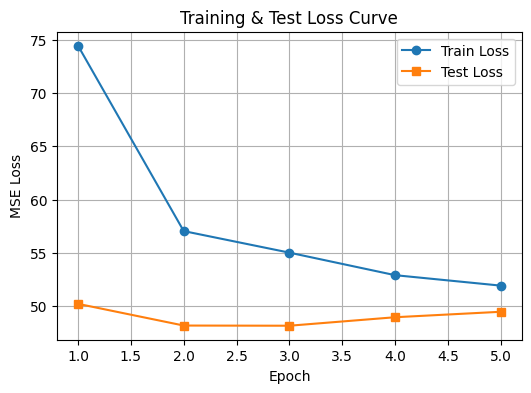


Processing EO branch: s2
Epoch 1/5 -> Train Loss: 54.6846, Test Loss: 48.1768
Epoch 2/5 -> Train Loss: 48.5337, Test Loss: 46.2137
Epoch 3/5 -> Train Loss: 49.7212, Test Loss: 48.2544
Epoch 4/5 -> Train Loss: 49.0708, Test Loss: 48.1282
Epoch 5/5 -> Train Loss: 51.0781, Test Loss: 48.8955


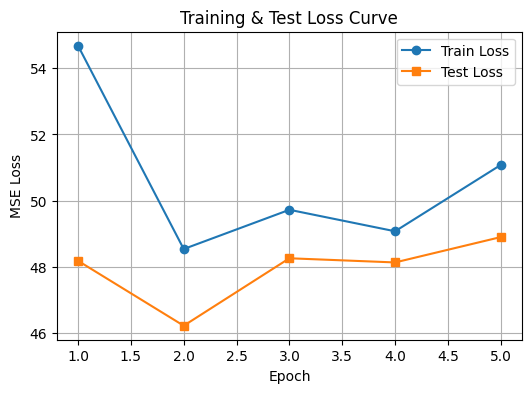


Processing EO branch: landsat
Epoch 1/5 -> Train Loss: 74.3612, Test Loss: 46.5447
Epoch 2/5 -> Train Loss: 55.8869, Test Loss: 45.5458
Epoch 3/5 -> Train Loss: 53.8827, Test Loss: 46.0151
Epoch 4/5 -> Train Loss: 50.2224, Test Loss: 47.1421
Epoch 5/5 -> Train Loss: 53.5985, Test Loss: 47.3423


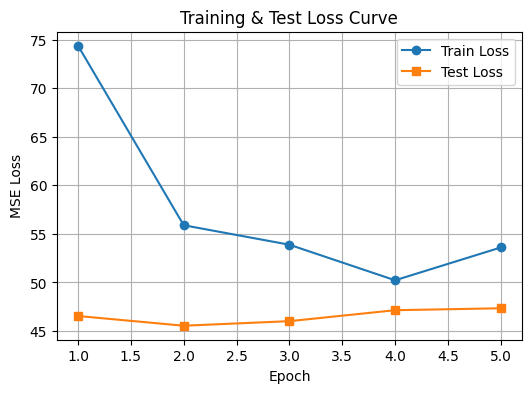


Processing EO branch: landsatidx
Epoch 1/5 -> Train Loss: 71.4385, Test Loss: 46.3996
Epoch 2/5 -> Train Loss: 57.1228, Test Loss: 45.5891
Epoch 3/5 -> Train Loss: 55.9556, Test Loss: 46.9152
Epoch 4/5 -> Train Loss: 49.6711, Test Loss: 48.5340
Epoch 5/5 -> Train Loss: 52.4642, Test Loss: 48.2469


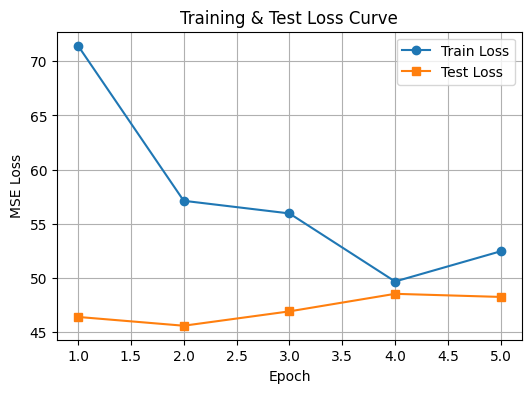


Processing EO branch: hls
Epoch 1/5 -> Train Loss: 67.3216, Test Loss: 46.2099
Epoch 2/5 -> Train Loss: 54.6697, Test Loss: 45.6004
Epoch 3/5 -> Train Loss: 52.2412, Test Loss: 46.3751
Epoch 4/5 -> Train Loss: 51.6783, Test Loss: 47.2508
Epoch 5/5 -> Train Loss: 51.6174, Test Loss: 47.6931


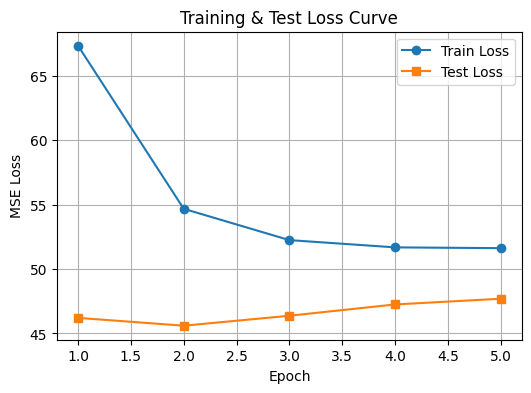


Processing EO branch: tcap
Epoch 1/5 -> Train Loss: 63.8733, Test Loss: 45.9810
Epoch 2/5 -> Train Loss: 54.9008, Test Loss: 45.6182
Epoch 3/5 -> Train Loss: 51.6632, Test Loss: 46.4187
Epoch 4/5 -> Train Loss: 53.5788, Test Loss: 46.7826
Epoch 5/5 -> Train Loss: 55.3821, Test Loss: 47.6481


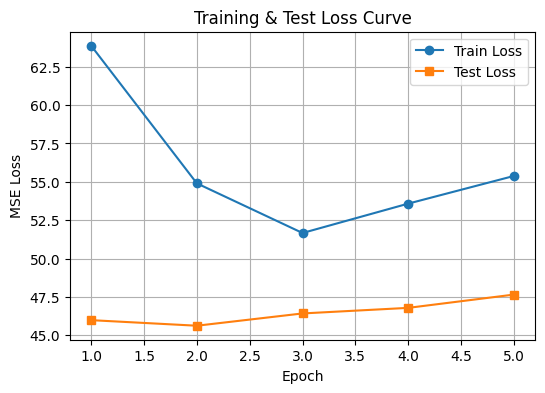


Processing EO branch: dem
Epoch 1/5 -> Train Loss: 70.5880, Test Loss: 46.6519
Epoch 2/5 -> Train Loss: 55.0374, Test Loss: 45.5532
Epoch 3/5 -> Train Loss: 50.6652, Test Loss: 46.6068
Epoch 4/5 -> Train Loss: 50.3154, Test Loss: 47.3014
Epoch 5/5 -> Train Loss: 50.5570, Test Loss: 47.6407


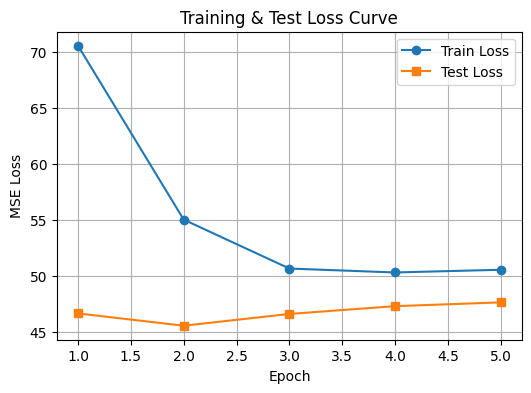


Processing EO branch: s2idx
Epoch 1/5 -> Train Loss: 95.0153, Test Loss: 50.2376
Epoch 2/5 -> Train Loss: 65.2275, Test Loss: 48.1352
Epoch 3/5 -> Train Loss: 58.9054, Test Loss: 46.8570
Epoch 4/5 -> Train Loss: 55.9617, Test Loss: 46.4554
Epoch 5/5 -> Train Loss: 54.3115, Test Loss: 46.8071


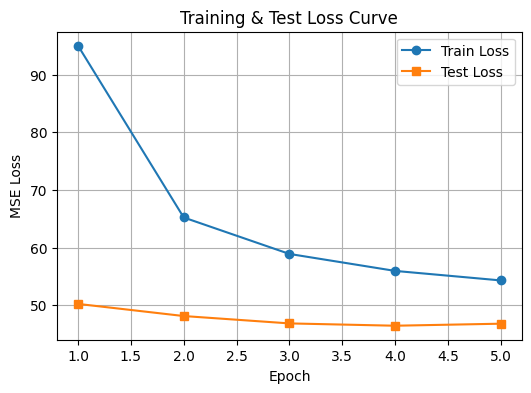

Epoch 1/5, Loss: 54564.4813
Epoch 2/5, Loss: 54108.3341
Epoch 3/5, Loss: 53704.3074
Epoch 4/5, Loss: 53332.2562
Epoch 5/5, Loss: 52965.8713


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




UMAP Modalities included:
 • s1
 • s2
 • landsat
 • landsatidx
 • hls
 • tcap
 • dem
 • s2idx
 • waveform


In [ ]:
# #//120 works good but dont not have test and val loaders in one full through put
# import torch
# import numpy as np

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # ----------------------------------
# # Collect all embeddings, store RH targets separately
# # ----------------------------------
# all_embeddings = {}
# all_RH_targets  = {}
# all_paths       = {}   # NEW: store paths

# modality_labels = []

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader  = test_loaders[branch_name]

#     # Build ViT encoder
#     in_channels = train_loader.dataset[0]["image"].shape[0]
#     model = ViTCustom(in_channels=in_channels)

#     # Train
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)

#     # Extract embeddings + paths
#     emb, targets, paths = extract_embeddings(model, train_loader, device=device)

#     all_embeddings[branch_name] = emb
#     all_RH_targets[branch_name] = targets
#     all_paths[branch_name] = paths

#     modality_labels.extend([branch_name] * emb.shape[0])


# # ----------------------------------
# # Add waveform autoencoder embeddings
# # ----------------------------------

# wave_model = WaveformAutoencoder(embed_dim=128)
# wave_model = train_waveform_autoencoder(wave_model, loader_rx, epochs=5, device=device)

# wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)

# all_embeddings["waveform"] = wave_emb.cpu()
# modality_labels.extend(["waveform"] * wave_emb.shape[0])


# # ----------------------------------
# # Build final UMAP input
# # ----------------------------------

# emb_all = torch.cat([all_embeddings[k] for k in all_embeddings.keys()], dim=0)
# labels_all = np.array(modality_labels)  # strings, not integers


# # ----------------------------------
# # UMAP Visualization with categorical colors
# # ----------------------------------

# visualize_umap_3d_string(
#     emb_all,
#     labels_all,           # now strings → categorical colors
#     title="UMAP 3D - All EO Modalities + Waveform"
# )

# print("\nUMAP Modalities included:")
# for name in all_embeddings.keys():
#     print(" •", name)


## Run: Train_loader VIT + Use for Test_loader, Val_loader

Stage 1 all lodaers are embeedings with all look ups

Saving encoders to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints

Training encoder: s1
Epoch 1/5 -> Train Loss: 74.7824, Test Loss: 50.2676
Epoch 2/5 -> Train Loss: 58.0149, Test Loss: 48.1880
Epoch 3/5 -> Train Loss: 55.7894, Test Loss: 48.0857
Epoch 4/5 -> Train Loss: 53.0603, Test Loss: 48.4993
Epoch 5/5 -> Train Loss: 52.6748, Test Loss: 49.0477


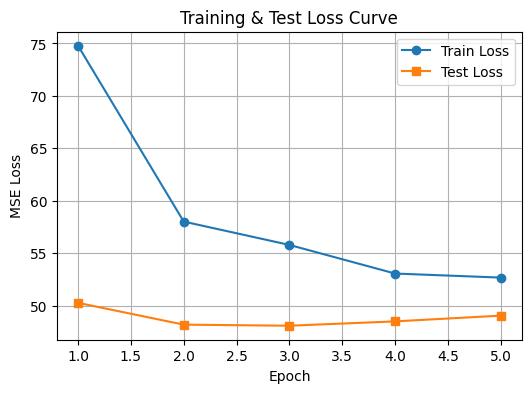

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_s1.pth

Training encoder: s2
Epoch 1/5 -> Train Loss: 58.1135, Test Loss: 48.6573
Epoch 2/5 -> Train Loss: 50.1725, Test Loss: 48.1400
Epoch 3/5 -> Train Loss: 48.7855, Test Loss: 48.4272
Epoch 4/5 -> Train Loss: 48.5601, Test Loss: 48.9250
Epoch 5/5 -> Train Loss: 49.8800, Test Loss: 47.2345


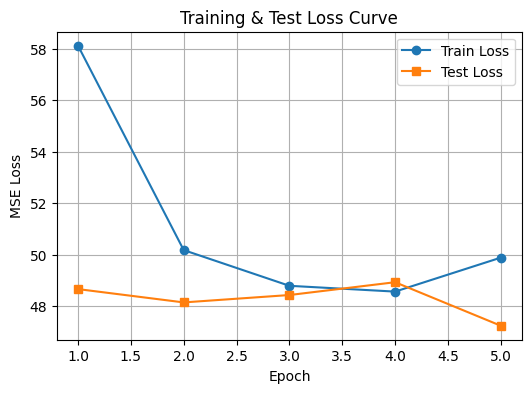

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_s2.pth

Training encoder: landsat
Epoch 1/5 -> Train Loss: 69.5535, Test Loss: 46.0511
Epoch 2/5 -> Train Loss: 55.8285, Test Loss: 45.7189
Epoch 3/5 -> Train Loss: 55.2231, Test Loss: 46.4106
Epoch 4/5 -> Train Loss: 52.8632, Test Loss: 47.6837
Epoch 5/5 -> Train Loss: 51.3821, Test Loss: 48.3914


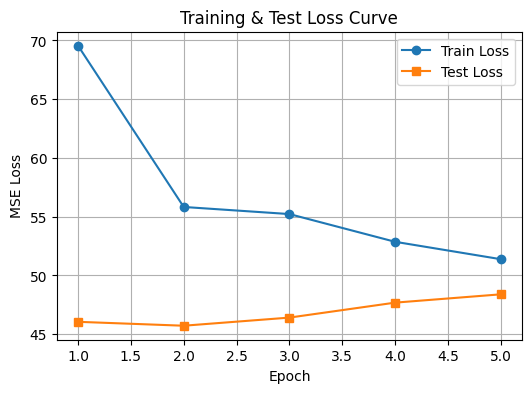

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_landsat.pth

Training encoder: landsatidx
Epoch 1/5 -> Train Loss: 69.5829, Test Loss: 46.1978
Epoch 2/5 -> Train Loss: 57.3531, Test Loss: 45.6049
Epoch 3/5 -> Train Loss: 51.6532, Test Loss: 46.8225
Epoch 4/5 -> Train Loss: 52.7126, Test Loss: 47.9563
Epoch 5/5 -> Train Loss: 52.4562, Test Loss: 47.6425


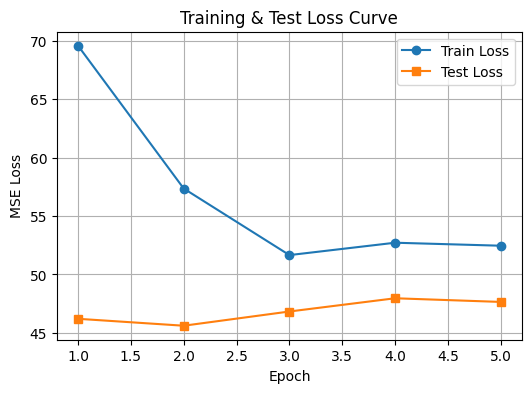

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_landsatidx.pth

Training encoder: hls
Epoch 1/5 -> Train Loss: 70.7773, Test Loss: 46.7427
Epoch 2/5 -> Train Loss: 55.5661, Test Loss: 45.5441
Epoch 3/5 -> Train Loss: 52.7113, Test Loss: 46.1943
Epoch 4/5 -> Train Loss: 51.7965, Test Loss: 47.2644
Epoch 5/5 -> Train Loss: 51.7753, Test Loss: 47.8484


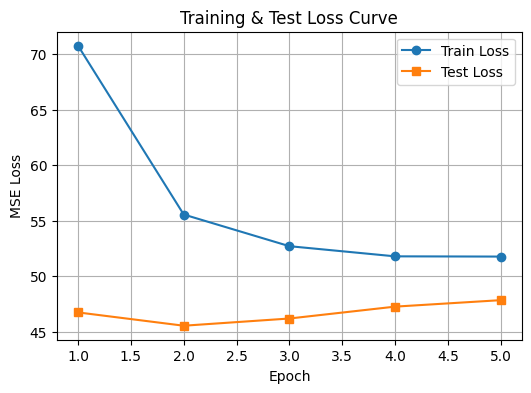

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_hls.pth

Training encoder: tcap
Epoch 1/5 -> Train Loss: 63.9719, Test Loss: 46.1678
Epoch 2/5 -> Train Loss: 56.7534, Test Loss: 45.7068
Epoch 3/5 -> Train Loss: 52.6971, Test Loss: 47.0678
Epoch 4/5 -> Train Loss: 53.7576, Test Loss: 48.2035
Epoch 5/5 -> Train Loss: 50.8670, Test Loss: 47.6206


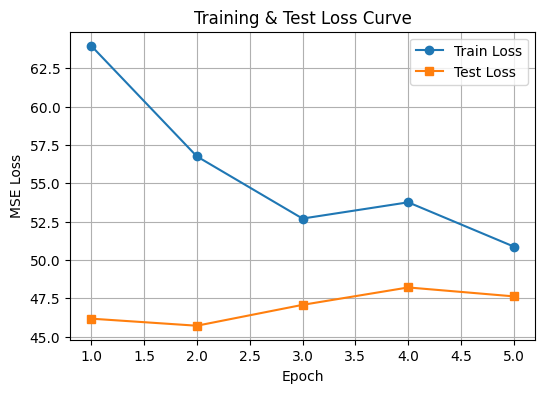

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_tcap.pth

Training encoder: dem
Epoch 1/5 -> Train Loss: 64.3047, Test Loss: 46.1893
Epoch 2/5 -> Train Loss: 54.6469, Test Loss: 45.6717
Epoch 3/5 -> Train Loss: 51.9785, Test Loss: 47.0207
Epoch 4/5 -> Train Loss: 53.8086, Test Loss: 47.2907
Epoch 5/5 -> Train Loss: 52.4455, Test Loss: 48.2219


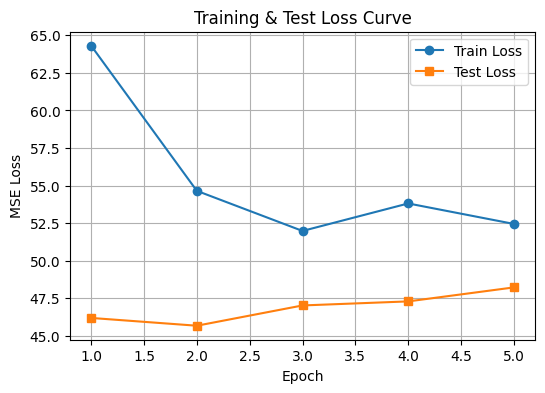

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_dem.pth

Training encoder: s2idx
Epoch 1/5 -> Train Loss: 89.9420, Test Loss: 50.2230
Epoch 2/5 -> Train Loss: 63.0658, Test Loss: 48.0358
Epoch 3/5 -> Train Loss: 58.7551, Test Loss: 46.8243
Epoch 4/5 -> Train Loss: 57.5464, Test Loss: 46.4508
Epoch 5/5 -> Train Loss: 54.4869, Test Loss: 46.8076


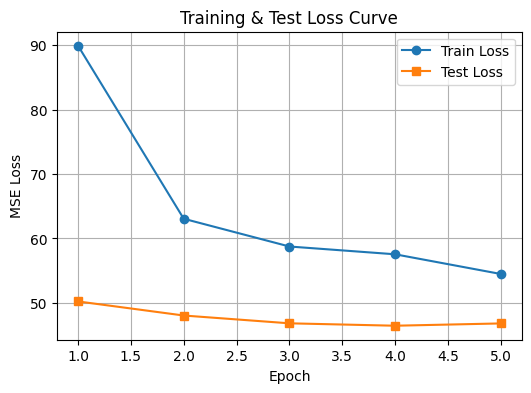

✓ Saved encoder → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints/encoder_s2idx.pth
Epoch 1/5, Loss: 20984.4588
Epoch 2/5, Loss: 8409.7441
Epoch 3/5, Loss: 5802.2610
Epoch 4/5, Loss: 5705.6517
Epoch 5/5, Loss: 5654.6179
✓ Saved waveform encoder

===== STAGE 1 COMPLETE =====
Encoders saved for all modalities!


In [152]:
#11/25

# ------------------------------------------------------------
# Create checkpoint directory
# ------------------------------------------------------------
CKPT_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Encoder_Checkpoints" # "checkpoints/encoders"
os.makedirs(CKPT_DIR, exist_ok=True)

print("Saving encoders to:", CKPT_DIR)


# =======================================================
#           RUN STAGE 1 (EO modalities)
# =======================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'

all_embeddings = {}
all_RH_targets = {}
all_paths = {}
all_trained_encoders = {}     # important

for branch_name in train_loaders.keys():
    print(f"\n====================")
    print(f"Training encoder: {branch_name}")
    print(f"====================")

    train_loader = train_loaders[branch_name]
    test_loader  = test_loaders[branch_name]

    in_channels = train_loader.dataset[0]["image"].shape[0]
    model = ViTCustom(in_channels=in_channels)

    # Train encoder
    model, head = train_vit_with_test_loss(model, train_loader, test_loader,
                                           epochs=5, device=device)

    # --------------------------------------------
    # SAVE ENCODER FOR STAGE 3 INFERENCE
    # --------------------------------------------
    save_path = os.path.join(CKPT_DIR, f"encoder_{branch_name}.pth")
    torch.save(model.state_dict(), save_path)

    print(f"✓ Saved encoder → {save_path}")

    # Keep in memory for Stage 1 extraction
    all_trained_encoders[branch_name] = model

    # Extract embeddings
    emb, tgt, paths = extract_embeddings(model, train_loader, device=device)

    all_embeddings[branch_name] = emb
    all_RH_targets[branch_name] = tgt
    all_paths[branch_name] = paths



# =======================================================
#        WAVEFORM AUTOENCODER (unchanged)
# =======================================================
# keep your existing WaveformAutoencoder implementation
# (only adding checkpoint saving)

wave_model = WaveformAutoencoder(embed_dim=128)
wave_model = train_waveform_autoencoder(wave_model, loader_rx,
                                        epochs=5, device=device)

wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)
all_embeddings["waveform"] = wave_emb.cpu()

torch.save(wave_model.state_dict(), os.path.join(CKPT_DIR, "encoder_waveform.pth"))
print("✓ Saved waveform encoder")

print("\n===== STAGE 1 COMPLETE =====")
print("Encoders saved for all modalities!")



Processing EO branch: s1
Epoch 1/5 -> Train Loss: 73.6632, Test Loss: 50.6529
Epoch 2/5 -> Train Loss: 58.9856, Test Loss: 48.4406
Epoch 3/5 -> Train Loss: 54.1305, Test Loss: 48.0100
Epoch 4/5 -> Train Loss: 53.5547, Test Loss: 48.6747
Epoch 5/5 -> Train Loss: 53.3480, Test Loss: 49.1363


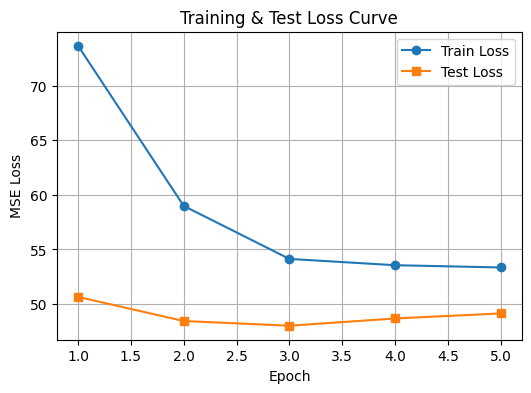


Processing EO branch: s2
Epoch 1/5 -> Train Loss: 56.7093, Test Loss: 48.4654
Epoch 2/5 -> Train Loss: 48.4467, Test Loss: 48.1544
Epoch 3/5 -> Train Loss: 49.2317, Test Loss: 48.4514
Epoch 4/5 -> Train Loss: 49.4516, Test Loss: 48.2499
Epoch 5/5 -> Train Loss: 49.3635, Test Loss: 47.1578


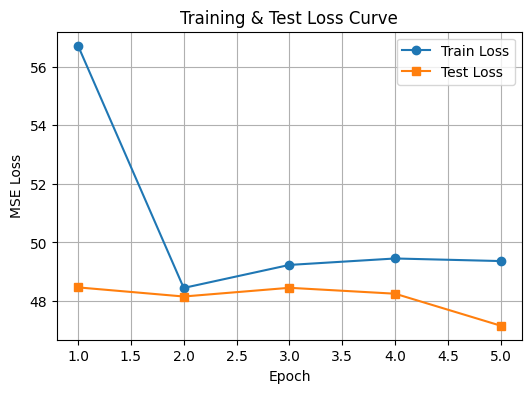


Processing EO branch: landsat
Epoch 1/5 -> Train Loss: 67.5935, Test Loss: 45.6681
Epoch 2/5 -> Train Loss: 55.3707, Test Loss: 46.1089
Epoch 3/5 -> Train Loss: 52.4113, Test Loss: 47.5741
Epoch 4/5 -> Train Loss: 52.1467, Test Loss: 48.8147
Epoch 5/5 -> Train Loss: 51.9458, Test Loss: 47.1329


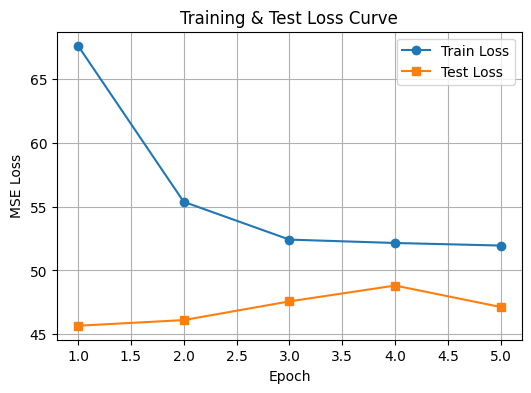


Processing EO branch: landsatidx
Epoch 1/5 -> Train Loss: 68.8130, Test Loss: 46.9982
Epoch 2/5 -> Train Loss: 57.2035, Test Loss: 45.5494
Epoch 3/5 -> Train Loss: 54.9873, Test Loss: 46.3239
Epoch 4/5 -> Train Loss: 53.7599, Test Loss: 47.2905
Epoch 5/5 -> Train Loss: 52.4415, Test Loss: 48.5205


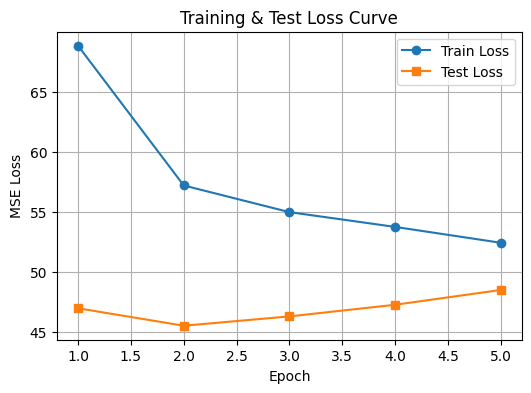


Processing EO branch: hls
Epoch 1/5 -> Train Loss: 72.2799, Test Loss: 46.6007
Epoch 2/5 -> Train Loss: 55.7308, Test Loss: 45.5417
Epoch 3/5 -> Train Loss: 52.6129, Test Loss: 46.0788
Epoch 4/5 -> Train Loss: 51.8656, Test Loss: 47.1007
Epoch 5/5 -> Train Loss: 51.6734, Test Loss: 47.7181


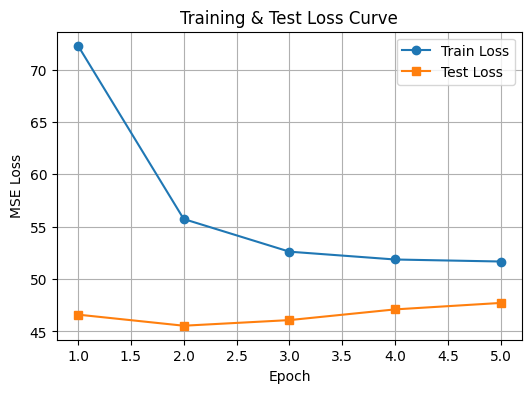


Processing EO branch: tcap
Epoch 1/5 -> Train Loss: 63.0027, Test Loss: 45.9140
Epoch 2/5 -> Train Loss: 55.2150, Test Loss: 45.7673
Epoch 3/5 -> Train Loss: 53.5998, Test Loss: 46.7776
Epoch 4/5 -> Train Loss: 53.5212, Test Loss: 47.7608
Epoch 5/5 -> Train Loss: 51.0027, Test Loss: 48.0239


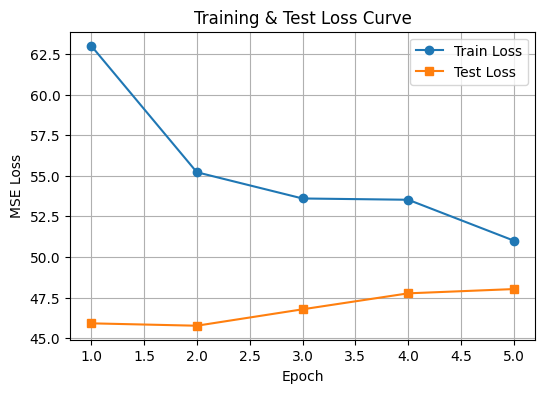


Processing EO branch: dem
Epoch 1/5 -> Train Loss: 71.8371, Test Loss: 46.7182
Epoch 2/5 -> Train Loss: 56.0342, Test Loss: 45.5309
Epoch 3/5 -> Train Loss: 51.8909, Test Loss: 46.0037
Epoch 4/5 -> Train Loss: 52.3320, Test Loss: 47.2608
Epoch 5/5 -> Train Loss: 53.3619, Test Loss: 47.2659


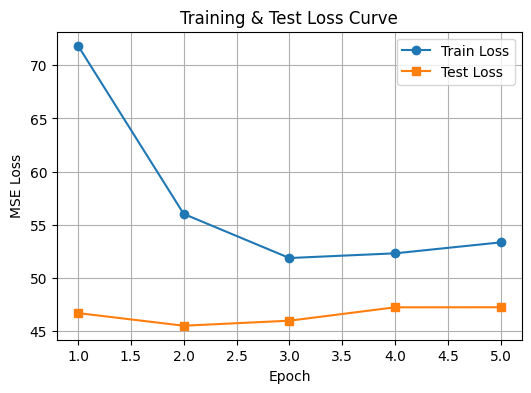


Processing EO branch: s2idx
Epoch 1/5 -> Train Loss: 86.6344, Test Loss: 49.0530
Epoch 2/5 -> Train Loss: 61.7378, Test Loss: 47.2547
Epoch 3/5 -> Train Loss: 60.6435, Test Loss: 46.5066
Epoch 4/5 -> Train Loss: 54.7721, Test Loss: 46.6017
Epoch 5/5 -> Train Loss: 53.2179, Test Loss: 47.2142


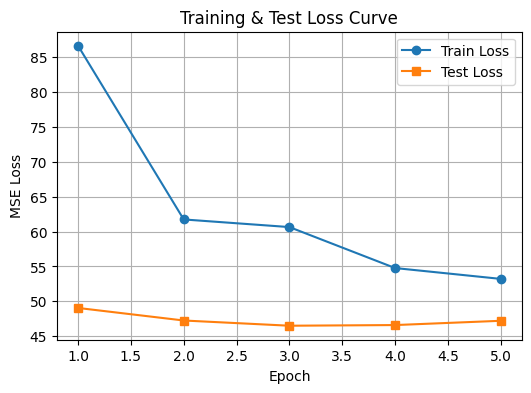

Epoch 1/5, Loss: 54743.1477
Epoch 2/5, Loss: 54221.8832
Epoch 3/5, Loss: 53765.6742
Epoch 4/5, Loss: 53377.3397
Epoch 5/5, Loss: 53003.3842

Processing EO branch for VAL/TEST embeddings: s1

Processing EO branch for VAL/TEST embeddings: s2

Processing EO branch for VAL/TEST embeddings: landsat

Processing EO branch for VAL/TEST embeddings: landsatidx

Processing EO branch for VAL/TEST embeddings: hls

Processing EO branch for VAL/TEST embeddings: tcap

Processing EO branch for VAL/TEST embeddings: dem

Processing EO branch for VAL/TEST embeddings: s2idx


In [75]:
#11/21 woks greta commented out as encoding checkpoints are not saved

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# # ----------------------------------
# # Stage 1: Train encoders and extract TRAIN embeddings
# # ----------------------------------

# all_embeddings = {}
# all_RH_targets  = {}
# all_paths       = {}
# modality_labels = []

# # NEW: store trained encoder per branch
# all_trained_encoders = {}

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch: {branch_name}")

#     train_loader = train_loaders[branch_name]
#     test_loader  = test_loaders[branch_name]

#     # Build ViT encoder
#     in_channels = train_loader.dataset[0]["image"].shape[0]
#     model = ViTCustom(in_channels=in_channels)

#     # Train
#     model, head = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)

#     # Save trained encoder in memory
#     all_trained_encoders[branch_name] = model

#     # Extract embeddings + paths for TRAIN
#     emb, targets, paths = extract_embeddings(model, train_loader, device=device)

#     all_embeddings[branch_name] = emb
#     all_RH_targets[branch_name] = targets
#     all_paths[branch_name] = paths
#     modality_labels.extend([branch_name] * emb.shape[0])

# # ----------------------------------
# # Add waveform autoencoder embeddings (unchanged)
# # ----------------------------------
# wave_model = WaveformAutoencoder(embed_dim=128)
# wave_model = train_waveform_autoencoder(wave_model, loader_rx, epochs=5, device=device)
# wave_emb = extract_waveform_embeddings(wave_model, loader_rx, device=device)
# all_embeddings["waveform"] = wave_emb.cpu()
# modality_labels.extend(["waveform"] * wave_emb.shape[0])

# # ----------------------------------
# # Stage 1: Extract frozen embeddings for VAL and TEST
# # ----------------------------------
# val_embeddings_dict  = {}
# val_targets_dict     = {}
# val_paths_dict       = {}

# test_embeddings_dict = {}
# test_targets_dict    = {}
# test_paths_dict      = {}

# for branch_name in train_loaders.keys():
#     print(f"\nProcessing EO branch for VAL/TEST embeddings: {branch_name}")

#     # Use the already trained encoder
#     model = all_trained_encoders[branch_name]
#     model.eval()

#     # VAL embeddings
#     val_emb, val_targets, val_paths = extract_embeddings(model, val_loaders[branch_name], device=device)
#     val_embeddings_dict[branch_name] = val_emb
#     val_targets_dict[branch_name]    = val_targets
#     val_paths_dict[branch_name]      = val_paths

#     # TEST embeddings
#     test_emb, test_targets, test_paths = extract_embeddings(model, test_loaders[branch_name], device=device)
#     test_embeddings_dict[branch_name] = test_emb
#     test_targets_dict[branch_name]    = test_targets
#     test_paths_dict[branch_name]      = test_paths


In [153]:
import numpy as np
import torch
import umap
import plotly.express as px

def visualize_umap_3d_split_ramps(embeddings, modalities, splits, targets=None, title_prefix="UMAP 3D"):
    """
    Produce 3 separate 3D UMAP plots, one per split:
    - EO modalities: gradient per split
    - Waveform: grey points included in all splits
    - Proper legend for modality names
    """
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    # Fit UMAP once on all embeddings
    reducer = umap.UMAP(n_components=3, random_state=42)
    emb_3d = reducer.fit_transform(embeddings)

    # Unique splits and EO modalities
    split_list = ['train', 'val', 'test']
    eo_modalities = sorted([m for m in set(modalities) if m != 'waveform'])

    # Precompute waveform mask and indices
    waveform_mask = np.array(modalities) == 'waveform'
    waveform_emb = emb_3d[waveform_mask]
    waveform_targets = np.array(targets)[waveform_mask] if targets is not None else None

    for split_name in split_list:
        mask_split = np.array(splits) == split_name
        # Include EO modalities for this split
        split_emb = emb_3d[mask_split & (~waveform_mask)]
        split_mods = np.array(modalities)[mask_split & (~waveform_mask)]
        split_targets = np.array(targets)[mask_split & (~waveform_mask)] if targets is not None else None

        # Combine EO + waveform for plotting
        plot_emb = np.vstack([split_emb, waveform_emb])
        plot_mods = np.concatenate([split_mods, np.array(['waveform']*waveform_emb.shape[0])])
        plot_targets = np.concatenate([
            split_targets if split_targets is not None else np.zeros(len(split_mods)),
            waveform_targets if waveform_targets is not None else np.zeros(len(waveform_emb))
        ])

        # Assign colors
        color_map = {}
        n_eo = len(eo_modalities)
        for i, mod in enumerate(eo_modalities):
            ramp_val = i / max(n_eo - 1, 1)
            if split_name == 'train':
                color_map[mod] = f'rgb(0,{int(50 + 205*ramp_val)},0)'  # green ramp
            elif split_name == 'val':
                color_map[mod] = f'rgb({int(50 + 205*ramp_val)},0,0)'  # red ramp
            elif split_name == 'test':
                color_map[mod] = f'rgb(0,0,{int(50 + 205*ramp_val)})'  # blue ramp
        # Waveform: grey
        color_map['waveform'] = 'rgb(150,150,150)'

        # Build hover text
        hover_text = [
            f"Modality: {m}<br>Split: {split_name}<br>Target: {t:.3f}"
            for m, t in zip(plot_mods, plot_targets)
        ]

        # Plot
        fig = px.scatter_3d(
            x=plot_emb[:,0],
            y=plot_emb[:,1],
            z=plot_emb[:,2],
            color=plot_mods,
            color_discrete_map=color_map,
            hover_name=hover_text,
            title=f"{title_prefix} - {split_name.upper()} Split"
        )
        fig.update_traces(marker=dict(size=4, line=dict(width=0)))
        fig.show()


works great visualize_umap_3d_split_ramps_save run if you want to save htmls (commented off)

In [ ]:

# def visualize_umap_3d_split_ramps_save(embeddings, modalities, splits, targets=None,
#                                        title_prefix="UMAP 3D", save_dir=None):
#     """
#     Same as before, but optionally saves each interactive plot as an HTML file.
#     save_dir : str or None
#         If provided, HTML files will be saved in this directory.
#     """
#     import os
#     if isinstance(embeddings, torch.Tensor):
#         embeddings = embeddings.cpu().numpy()

#     reducer = umap.UMAP(n_components=3, random_state=42)
#     emb_3d = reducer.fit_transform(embeddings)

#     split_list = ['train', 'val', 'test']
#     eo_modalities = sorted([m for m in set(modalities) if m != 'waveform'])

#     waveform_mask = np.array(modalities) == 'waveform'
#     waveform_emb = emb_3d[waveform_mask]
#     waveform_targets = np.array(targets)[waveform_mask] if targets is not None else None

#     if save_dir is not None:
#         os.makedirs(save_dir, exist_ok=True)

#     for split_name in split_list:
#         mask_split = np.array(splits) == split_name
#         split_emb = emb_3d[mask_split & (~waveform_mask)]
#         split_mods = np.array(modalities)[mask_split & (~waveform_mask)]
#         split_targets = np.array(targets)[mask_split & (~waveform_mask)] if targets is not None else None

#         plot_emb = np.vstack([split_emb, waveform_emb])
#         plot_mods = np.concatenate([split_mods, np.array(['waveform']*waveform_emb.shape[0])])
#         plot_targets = np.concatenate([
#             split_targets if split_targets is not None else np.zeros(len(split_mods)),
#             waveform_targets if waveform_targets is not None else np.zeros(len(waveform_emb))
#         ])

#         # Colors
#         color_map = {}
#         n_eo = len(eo_modalities)
#         for i, mod in enumerate(eo_modalities):
#             ramp_val = i / max(n_eo - 1, 1)
#             if split_name == 'train':
#                 color_map[mod] = f'rgb(0,{int(50 + 205*ramp_val)},0)'
#             elif split_name == 'val':
#                 color_map[mod] = f'rgb({int(50 + 205*ramp_val)},0,0)'
#             elif split_name == 'test':
#                 color_map[mod] = f'rgb(0,0,{int(50 + 205*ramp_val)})'
#         color_map['waveform'] = 'rgb(150,150,150)'

#         hover_text = [
#             f"Modality: {m}<br>Split: {split_name}<br>Target: {t:.3f}"
#             for m, t in zip(plot_mods, plot_targets)
#         ]

#         fig = px.scatter_3d(
#             x=plot_emb[:,0],
#             y=plot_emb[:,1],
#             z=plot_emb[:,2],
#             color=plot_mods,
#             color_discrete_map=color_map,
#             hover_name=hover_text,
#             title=f"{title_prefix} - {split_name.upper()} Split"
#         )
#         fig.update_traces(marker=dict(size=4, line=dict(width=0)))
#         fig.show()

#         # Save HTML
#         if save_dir is not None:
#             filename = os.path.join(save_dir, f"{title_prefix}_{split_name}.html")
#             fig.write_html(filename)
#             print(f"Saved interactive plot: {filename}")


In [154]:
import torch
import numpy as np

# ----------------------------------
# Combine embeddings for UMAP
# ----------------------------------

# TRAIN embeddings + waveform
train_emb_all = torch.cat([all_embeddings[k] for k in all_embeddings.keys()], dim=0)
train_labels  = np.array(modality_labels)

# VAL embeddings
val_emb_all = torch.cat([val_embeddings_dict[k] for k in val_embeddings_dict.keys()], dim=0)
val_labels  = np.array([k for k in val_embeddings_dict.keys() for _ in range(val_embeddings_dict[k].shape[0])])

# TEST embeddings
test_emb_all = torch.cat([test_embeddings_dict[k] for k in test_embeddings_dict.keys()], dim=0)
test_labels  = np.array([k for k in test_embeddings_dict.keys() for _ in range(test_embeddings_dict[k].shape[0])])

# Combine embeddings
all_emb_all = torch.cat([train_emb_all, val_emb_all, test_emb_all], dim=0)
all_modalities = np.concatenate([train_labels, val_labels, test_labels])

# ----------------------------------
# Build split labels
# ----------------------------------
train_split = ['train'] * train_emb_all.shape[0]
val_split   = ['val']   * val_emb_all.shape[0]
test_split  = ['test']  * test_emb_all.shape[0]
all_splits  = np.array(train_split + val_split + test_split)

# ----------------------------------
# Build target array
# ----------------------------------
# For EO modalities
train_targets = np.concatenate([
    all_RH_targets[k].cpu().numpy() if isinstance(all_RH_targets[k], torch.Tensor)
    else np.array(all_RH_targets[k]) for k in all_RH_targets.keys()
])
val_targets = np.concatenate([
    val_targets_dict[k].cpu().numpy() if isinstance(val_targets_dict[k], torch.Tensor)
    else np.array(val_targets_dict[k]) for k in val_targets_dict.keys()
])
test_targets = np.concatenate([
    test_targets_dict[k].cpu().numpy() if isinstance(test_targets_dict[k], torch.Tensor)
    else np.array(test_targets_dict[k]) for k in test_targets_dict.keys()
])

# For waveform embeddings, use dummy target (or set NaN)
wave_train_len = all_embeddings["waveform"].shape[0]
wave_val_len   = 0  # if you didn't extract val/test for waveform
wave_test_len  = 0

wave_train_targets = np.full(wave_train_len, np.nan)
wave_val_targets   = np.full(wave_val_len, np.nan)
wave_test_targets  = np.full(wave_test_len, np.nan)

all_targets = np.concatenate([
    train_targets, wave_train_targets,
    val_targets, wave_val_targets,
    test_targets, wave_test_targets
])

# ----------------------------------
# Visualize
# ----------------------------------
visualize_umap_3d_split_ramps(
    all_emb_all, all_modalities, all_splits, targets=all_targets,
    title_prefix="UMAP 3D - Modalities + Split + Target"
)

#####call for running save html figures commente doff above
# visualize_umap_3d_split_ramps_save(
#     all_emb_all, all_modalities, all_splits, targets=all_targets,
#     title_prefix="UMAP 3D - Modalities + Split + Target",
#     save_dir="umap_html_plots"
# )



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



In [155]:
# Iterate through the dictionary and print the counts and lengths
for key, tensor_value in all_embeddings.items():
    # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
    # The first element (index 0) is the count (rows/entries).
    count_x = tensor_value.shape[0]
    # The second element (index 1) is the length (columns/embedding dimension).
    length_y = tensor_value.shape[1]

    print(f"train {key}: count {count_x}, length {length_y}")


train s1: count 165, length 128
train s2: count 371, length 128
train landsat: count 194, length 128
train landsatidx: count 194, length 128
train hls: count 192, length 128
train tcap: count 194, length 128
train dem: count 194, length 128
train s2idx: count 104, length 128
train waveform: count 3846, length 128


In [156]:
# Iterate through the dictionary and print the counts and lengths
for key, tensor_value in test_embeddings_dict.items():
    # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
    # The first element (index 0) is the count (rows/entries).
    count_x = tensor_value.shape[0]
    # The second element (index 1) is the length (columns/embedding dimension).
    length_y = tensor_value.shape[1]

    print(f"test val {key}: count {count_x}, length {length_y}")


test val s1: count 48, length 128
test val s2: count 92, length 128
test val landsat: count 42, length 128
test val landsatidx: count 42, length 128
test val hls: count 42, length 128
test val tcap: count 42, length 128
test val dem: count 42, length 128
test val s2idx: count 22, length 128


In [157]:
# Iterate through the dictionary and print the counts and lengths
for key, tensor_value in val_embeddings_dict.items():
    # The shape attribute of a torch.Tensor gives its dimensions as a tuple.
    # The first element (index 0) is the count (rows/entries).
    count_x = tensor_value.shape[0]
    # The second element (index 1) is the length (columns/embedding dimension).
    length_y = tensor_value.shape[1]

    print(f"val {key}: count {count_x}, length {length_y}")

val s1: count 24, length 128
val s2: count 51, length 128
val landsat: count 24, length 128
val landsatidx: count 24, length 128
val hls: count 24, length 128
val tcap: count 24, length 128
val dem: count 24, length 128
val s2idx: count 11, length 128


In [158]:
# Iterate through the dictionary and print the count/length
for key, tensor_value in all_RH_targets.items():
    # For a 1D tensor, the shape has only one element (the length/count).
    count_y = tensor_value.shape[0]

    # The request format was "s1: count x, length y"
    # We can interpret 'count x' as the total number of items in the tensor.
    print(f"{key}: count {count_y}, length {count_y}")

s1: count 165, length 165
s2: count 371, length 371
landsat: count 194, length 194
landsatidx: count 194, length 194
hls: count 192, length 192
tcap: count 194, length 194
dem: count 194, length 194
s2idx: count 104, length 104


## Collapse embeddings to row_ID targets

In [159]:
df_train = df_valid[df_valid["split_x"] == "train"]


In [160]:
path_to_rowid = dict(zip(df_train["full_path"], df_train["row_ID"]))
path_to_target = dict(zip(df_train["full_path"], df_train["rh"]))   # your target column


In [161]:
print("Example:", next(iter(path_to_rowid.items())))


Example: ('/content/processed_32x32_normalized/tcap_train_GEDI_L2A_2020196021509_35_block_5933899.tif', 35)


In [162]:
from collections import defaultdict

# Dictionary to hold embeddings per row_ID
collapsed_embeddings = defaultdict(list)
collapsed_targets = {}

# Only iterate EO modalities that have paths
eo_modalities = [mod for mod in all_embeddings.keys() if mod != "waveform"]

for mod in eo_modalities:
    paths = all_paths[mod]   # list of file paths
    emb   = all_embeddings[mod]

    for i, p in enumerate(paths):
        # find row_ID in df_valid
        row_id = df_valid.loc[df_valid['full_path'] == p, 'row_ID'].values[0]

        collapsed_embeddings[row_id].append(emb[i])

        # set RH target for this row_ID (only once)
        if row_id not in collapsed_targets:
            collapsed_targets[row_id] = all_RH_targets[mod][i]


In [163]:
collapsed_targets

{np.int64(712): tensor(2.9670),
 np.int64(571): tensor(1.8379),
 np.int64(505): tensor(14.1146),
 np.int64(252): tensor(3.8984),
 np.int64(537): tensor(9.1920),
 np.int64(513): tensor(10.3975),
 np.int64(619): tensor(20.4520),
 np.int64(995): tensor(17.5476),
 np.int64(1837): tensor(3.2034),
 np.int64(1596): tensor(21.0260),
 np.int64(1102): tensor(17.8987),
 np.int64(1309): tensor(3.6210),
 np.int64(1205): tensor(3.0133),
 np.int64(1593): tensor(17.7016),
 np.int64(755): tensor(4.4180),
 np.int64(1244): tensor(2.9155),
 np.int64(534): tensor(-0.3954),
 np.int64(911): tensor(-0.3436),
 np.int64(1843): tensor(3.5240),
 np.int64(1190): tensor(3.1039),
 np.int64(296): tensor(6.9895),
 np.int64(1289): tensor(7.7515),
 np.int64(767): tensor(2.3443),
 np.int64(1025): tensor(17.6909),
 np.int64(886): tensor(-0.2774),
 np.int64(1026): tensor(16.6523),
 np.int64(658): tensor(16.7986),
 np.int64(1524): tensor(15.6943),
 np.int64(207): tensor(16.6571),
 np.int64(53): tensor(13.4973),
 np.int64(40

In [164]:
dataset = []

for row_id in collapsed_targets.keys():
    sample = {
        "row_ID": row_id,
        "embeddings": torch.stack(collapsed_embeddings[row_id]),  # [N_tokens, 128]
        "target": collapsed_targets[row_id].float()               # scalar
    }
    dataset.append(sample)

print(f"Total samples: {len(dataset)}")
print("Example sample shapes:")
print("row_ID:", dataset[0]['row_ID'])
print("embeddings:", dataset[0]['embeddings'].shape)
print("target:", dataset[0]['target'])


Total samples: 488
Example sample shapes:
row_ID: 712
embeddings: torch.Size([1, 128])
target: tensor(2.9670)


Stage 1 complete now frozen

# Stage 2

2 — Fusion training	Train embeddings	Fusion model	learn to predict RH

2 — Fusion validation	Val embeddings	Val loss / metrics	tune

2 — Fusion test	Test embeddings	Test metrics	evaluate


In [165]:
import torch

# Example: create a single batch (all samples) for training
# Train EO modalities
# Train EO modalities
train_eo_emb = {k: v.detach().clone() if isinstance(v, torch.Tensor) else torch.tensor(v)
                for k, v in all_embeddings.items() if k != 'waveform'}

train_wave_emb = all_embeddings['waveform'].detach().clone() if isinstance(all_embeddings['waveform'], torch.Tensor) else torch.tensor(all_embeddings['waveform'])

# Targets (take reference from s1)
train_targets = all_RH_targets['s1'].detach().clone() if isinstance(all_RH_targets['s1'], torch.Tensor) else torch.tensor(all_RH_targets['s1'])


# Make a batch_dict for model input
train_batch_dict = {**train_eo_emb, 'waveform': train_wave_emb}

# Check shapes
for k, v in train_batch_dict.items():
    print(f"{k}: {v.shape}")
print("targets:", train_targets.shape)



s1: torch.Size([165, 128])
s2: torch.Size([371, 128])
landsat: torch.Size([194, 128])
landsatidx: torch.Size([194, 128])
hls: torch.Size([192, 128])
tcap: torch.Size([194, 128])
dem: torch.Size([194, 128])
s2idx: torch.Size([104, 128])
waveform: torch.Size([3846, 128])
targets: torch.Size([165])


In [166]:
import torch
from torch.utils.data import Dataset

class RowIDDataset(Dataset):
    def __init__(self, collapsed_embeddings, collapsed_targets):
        self.row_ids = list(collapsed_targets.keys())
        self.collapsed_embeddings = collapsed_embeddings
        self.collapsed_targets = collapsed_targets

    def __len__(self):
        return len(self.row_ids)

    def __getitem__(self, idx):
        row_id = self.row_ids[idx]
        emb_list = self.collapsed_embeddings[row_id]  # list of tensors
        target = self.collapsed_targets[row_id]

        tokens = torch.stack(emb_list)  # [N_tokens, 128]
        return tokens, target.float()


In [167]:
def collate_fn(batch):
    tokens_list, targets_list = zip(*batch)
    max_len = max(t.shape[0] for t in tokens_list)
    embed_dim = tokens_list[0].shape[1]

    padded_tokens = []
    for t in tokens_list:
        pad_len = max_len - t.shape[0]
        if pad_len > 0:
            padding = torch.zeros(pad_len, embed_dim)
            t = torch.cat([t, padding], dim=0)
        padded_tokens.append(t)

    tokens_batch = torch.stack(padded_tokens)  # [B, max_len, embed_dim]
    targets_batch = torch.stack(targets_list)  # [B]
    return tokens_batch, targets_batch


In [168]:
from torch.utils.data import DataLoader

dataset_obj = RowIDDataset(collapsed_embeddings, collapsed_targets)
loader = DataLoader(dataset_obj, batch_size=16, shuffle=True, collate_fn=collate_fn)


In [169]:
import torch.nn as nn

class MultimodalAttentionRegressor(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.head = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: [B, N_tokens, embed_dim]
        attn_out, _ = self.attn(x, x, x)
        pooled = attn_out.mean(dim=1)  # mean pooling over tokens
        out = self.head(pooled)        # [B, 1]
        return out.squeeze(1)           # [B]


Epoch 1/10 — Loss: 82.55408
Epoch 2/10 — Loss: 61.51290
Epoch 3/10 — Loss: 57.52421
Epoch 4/10 — Loss: 49.60343
Epoch 5/10 — Loss: 50.09959
Epoch 6/10 — Loss: 49.10183
Epoch 7/10 — Loss: 47.24985
Epoch 8/10 — Loss: 47.35591
Epoch 9/10 — Loss: 47.22004
Epoch 10/10 — Loss: 46.14307


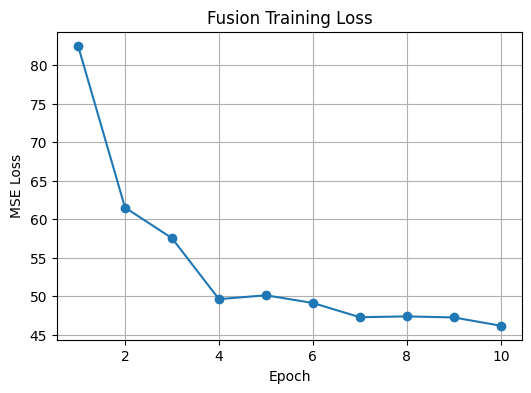

✅ Fusion model saved to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_regressor.pth
✅ TorchScript model saved to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_regressor_script.pt


In [170]:
############################################################
# 5. Training Loop
############################################################

model = MultimodalAttentionRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

loss_history = []

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for tokens, targets in loader:
        tokens = tokens.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        preds = model(tokens)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * tokens.size(0)

    epoch_loss = total_loss / len(dataset_obj)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss:.5f}")


############################################################
# 6. Plot Loss
############################################################

plt.figure(figsize=(6,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Fusion Training Loss")
plt.grid(True)
plt.show()


############################################################
# 7. SAVE FUSION MODEL  (needed for Stage 3 inference)
############################################################

SAVE_PATH = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models/Stage_2_fusion_regressor.pth"

# --- Recommended format ---
torch.save({
    "model_state_dict": model.state_dict(),
    "epoch": EPOCHS,
    "loss_history": loss_history,
}, SAVE_PATH)

print("✅ Fusion model saved to:", SAVE_PATH)

# Optional: also save torchscript for portability
SCRIPT_PATH = SAVE_PATH.replace(".pth", "_script.pt")
traced = torch.jit.trace(model, torch.randn(1, 10, 128).to(device))
torch.jit.save(traced, SCRIPT_PATH)

print("✅ TorchScript model saved to:", SCRIPT_PATH)

# Stage 3

### Prep Inference (Simialr to before for training)

In [182]:

import os

EO_inference_folder = "/content/EO_inference_folder"
os.makedirs(EO_inference_folder, exist_ok=True)

print("EO_inference_folder:", EO_inference_folder)

EO_inference_folder: /content/EO_inference_folder


### Move Inference tifs

In [183]:
import os
import shutil

src_dir = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/32x32_patches"
dst_dir = "/content/EO_inference_folder"

# Create destination folder if not existing
os.makedirs(dst_dir, exist_ok=True)

# Move all .tif files
for file in os.listdir(src_dir):
    if file.endswith(".tif"):
        shutil.copy2(os.path.join(src_dir, file), os.path.join(dst_dir, file))

print("Finished copying TIFF files!")


Finished copying TIFF files!


Investigate INF a set of Tifs before modifying/prepping

In [184]:
import os
import random


# list only .tif files in the folder
selected_files = [f for f in os.listdir(dst_dir) if f.lower().endswith(".tif")]

# sample 5 files
sample_files_Inf = random.sample(selected_files, 5)
sample_files_Inf


['s1Ascending_2024_0014_0042.tif',
 'DEMindices_2024_0002_0000.tif',
 'S2Composite_2024_0023_0012.tif',
 's1Ascending_2024_0023_0016.tif',
 'HLS_2024_0005_0009.tif']


FILE: s1Ascending_2024_0014_0042.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 10.0 x 10.0 (approx meters)

  Band 1 statistics:
      min:  -13.511698946877097
      max:  -3.6908842214123965
      mean: -8.726003741401591
      std:  1.8198543671068057

  Band 2 statistics:
      min:  -20.082775452487567
      max:  -11.361001930909673
      mean: -14.69815473652331
      std:  1.88639159453277

  Band 3 statistics:
      min:  0.24716515774514797
      max:  0.7141564743094465
      mean: 0.588949109968107
      std:  0.05844134673499657

  Band 4 statistics:
      min:  -0.603636845993969
      max:  -0.16675462828194051
      mean: -0.2605020131300813
      std:  0.049373543632435984


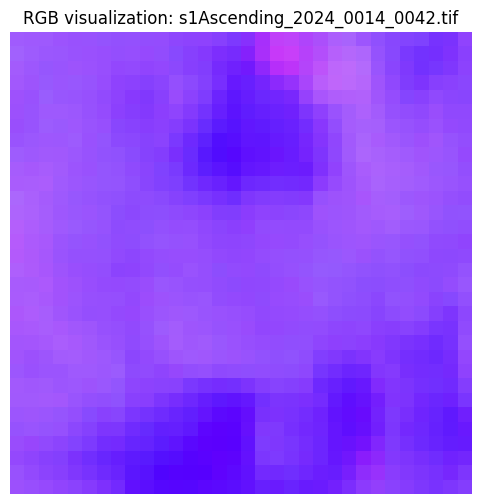


FILE: DEMindices_2024_0002_0000.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  353.6582336425781
      max:  595.2059326171875
      mean: 468.79668268950087
      std:  54.253910959125925

  Band 2 statistics:
      min:  2.454352378845215
      max:  29.307079315185547
      mean: 15.52299146613349
      std:  4.762069516304378
Skipping visualization for DEMindices_2024_0002_0000.tif: unsupported band count.


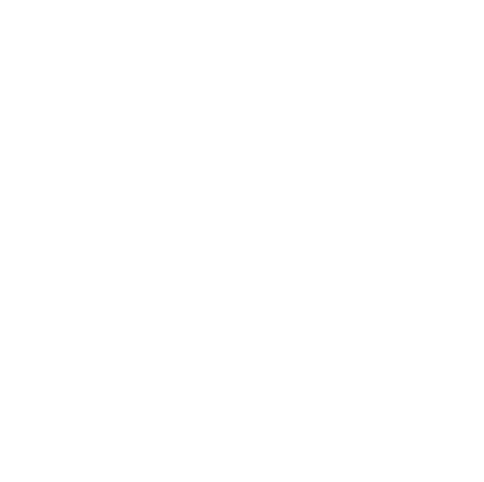


FILE: S2Composite_2024_0023_0012.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.03346666693687439
      max:  0.12745556235313416
      mean: 0.05027578308727243
      std:  0.00770511696467826

  Band 2 statistics:
      min:  0.04160434752702713
      max:  0.12859167158603668
      mean: 0.04925408462804626
      std:  0.006729532069613148

  Band 3 statistics:
      min:  0.025818750262260437
      max:  0.10605555772781372
      mean: 0.03301170616032323
      std:  0.005937653200152946

  Band 4 statistics:
      min:  0.19189999997615814
      max:  0.36841249465942383
      mean: 0.2559560618683463
      std:  0.032957450612770646

  Band 5 statistics:
      min:  0.16963332891464233
      max:  0.2561500072479248
      mean: 0.20438294764608145
      std:  0.010947923429426893

  Band 6 statistics:
      min:  0.0870250016450882
      max:  0.16132499277591705
      mean: 0.10497459760

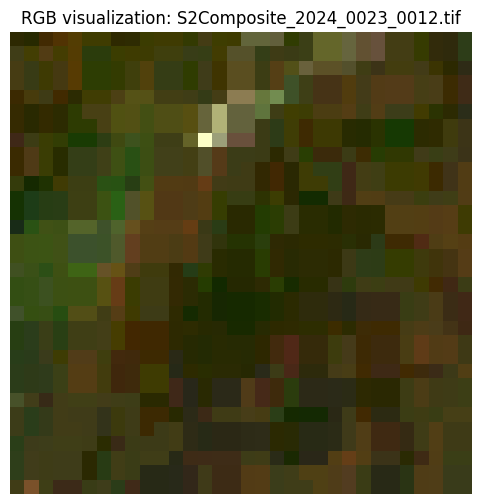


FILE: s1Ascending_2024_0023_0016.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 10.0 x 10.0 (approx meters)

  Band 1 statistics:
      min:  -10.51959488994104
      max:  -5.610852866522911
      mean: -8.641791871309284
      std:  0.8802205242248661

  Band 2 statistics:
      min:  -18.356289203203588
      max:  -11.996917542279125
      mean: -15.536444575743765
      std:  1.1947040816036474

  Band 3 statistics:
      min:  0.45093151936094
      max:  0.6245290159972507
      mean: 0.5554302102308996
      std:  0.024999344044536232

  Band 4 statistics:
      min:  -0.37842480731337075
      max:  -0.23112605580163104
      mean: -0.2861523715522053
      std:  0.020817504489628966


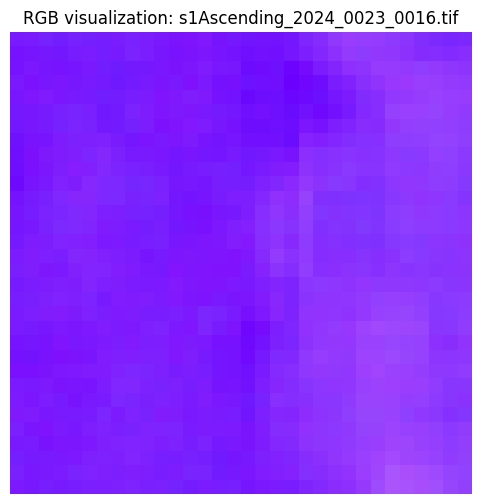


FILE: HLS_2024_0005_0009.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  -0.5147058963775635
      max:  0.7991513609886169
      mean: 0.5630646339834553
      std:  0.12379389822088839

  Band 2 statistics:
      min:  -0.8111058473587036
      max:  0.75
      mean: -0.5813933250124323
      std:  0.11241266142157653

  Band 3 statistics:
      min:  -0.7777777910232544
      max:  0.9178082346916199
      mean: -0.5388502215753552
      std:  0.09931293276956563

  Band 4 statistics:
      min:  -0.07603686302900314
      max:  0.4638655483722687
      mean: 0.3118392793221574
      std:  0.06727572323375472

  Band 5 statistics:
      min:  -0.3307613134384155
      max:  0.2504592835903168
      mean: 0.06635318634903832
      std:  0.07661426015712668

  Band 6 statistics:
      min:  -0.2504592835903168
      max:  0.3307613134384155
      mean: -0.06635318634903832
      std:  0.076614260

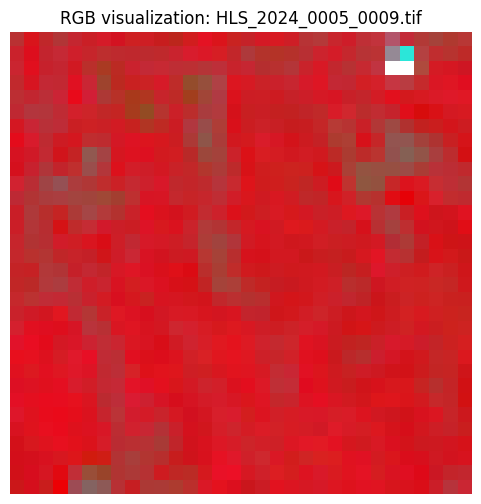

In [185]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files_Inf:
    fpath = os.path.join(dst_dir, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)

            plt.imshow(img)
            plt.title(f"RGB visualization: {fname}")

        elif count == 1:
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Single-band grayscale: {fname}")

        else:
            print(f"Skipping visualization for {fname}: unsupported band count.")

        plt.axis('off')
        plt.show()


### Prep tifs: Pad, Normalize, inspect, save to content

In [186]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# -------------------------------------------------------------------------

# PROCESSED_DIR = "/content/processed_32x32_normalized"
dst_dir = "/content/EO_inference_folder"
os.makedirs(dst_dir, exist_ok=True)

print("Scanning directory:", dst_dir)

all_tifs = [
    f for f in os.listdir(dst_dir)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0
dropped_files = 0

print(f"\nFound {total_files} TIFFs in {dst_dir}\n")

selected_files = []   # <-- Files that pass checks
dropped_list = []     # <-- Files to delete


for fname in all_tifs:
    fpath = os.path.join(dst_dir, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False
        too_many_nans = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True
            if nan_count >= 1024: #100:
                too_many_nans = True

            bands.append(data)

    # Drop files with too many NaNs
    if too_many_nans:
        dropped_files += 1
        dropped_list.append(fname)     # <--- NOW correctly recorded
        print(f"DROPPED: {fname} (≥100 NaNs)")
        continue

    # Fix files that have ≤99 NaNs
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                med = np.nanmedian(data)
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep this TIFF for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

print("Dropped files:", dropped_list)

# -------------------------------------------------------------------------
# DELETE DROPPED FILES
# -------------------------------------------------------------------------
print("\nDeleting dropped TIFF files...\n")

for fname in dropped_list:
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        os.remove(fpath)
        print("Deleted:", fname)

print("\nFinished deleting dropped TIFFs.")
print("Total deleted files:", len(dropped_list))


Scanning directory: /content/EO_inference_folder

Found 5780 TIFFs in /content/EO_inference_folder

FIXING: HLS_2024_0016_0016.tif (median fill)
FIXING: S2Composite_2024_0002_0026.tif (median fill)
FIXING: HLS_2024_0000_0009.tif (median fill)
FIXING: LandsatIndices_2024_0015_0016.tif (median fill)
FIXING: DEMindices_2024_0007_0017.tif (median fill)
FIXING: s1Ascending_2024_0051_0042.tif (median fill)
FIXING: S2Indices_2024_0025_0012.tif (median fill)
FIXING: HLS_2024_0016_0010.tif (median fill)
FIXING: LandsatIndices_2024_0014_0000.tif (median fill)
FIXING: s1Ascending_2024_0050_0041.tif (median fill)
FIXING: HLS_2024_0005_0010.tif (median fill)
FIXING: s1Ascending_2024_0007_0001.tif (median fill)
FIXING: S2Indices_2024_0008_0026.tif (median fill)
FIXING: landsatTasseledCapIndices_2024_0002_0017.tif (median fill)
FIXING: LandsatComposite_2024_0003_0016.tif (median fill)
FIXING: S2Composite_2024_0001_0026.tif (median fill)
FIXING: s1Ascending_2024_0045_0052.tif (median fill)
FIXING: S2C

In [193]:
import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling
import numpy as np
import os

import rasterio
from rasterio.transform import Affine
from rasterio.enums import Resampling
import numpy as np
import os

# Pre-existing functions
def resize_to_max32(src):
    h = src.height
    w = src.width
    bands = src.count

    if h <= 32 and w <= 32:
        return src.read(), src.transform

    scale_h = 32 / h
    scale_w = 32 / w
    scale = min(scale_h, scale_w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    resized = src.read(
        out_shape=(bands, new_h, new_w),
        resampling=Resampling.bilinear
    )

    new_transform = Affine(
        src.transform.a / scale, src.transform.b, src.transform.c,
        src.transform.d, src.transform.e / scale, src.transform.f
    )

    return resized, new_transform

def pad_to_32x32(arr, transform):
    bands, h, w = arr.shape
    padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

    h_start = (32 - h) // 2
    w_start = (32 - w) // 2

    padded[:, h_start:h_start+h, w_start:w_start+w] = arr
    new_transform = transform * Affine.translation(-w_start, -h_start)
    return padded, new_transform

def minmax_normalize(arr):
    arr = arr.astype(float)
    for b in range(arr.shape[0]):
        mn = np.nanmin(arr[b])
        mx = np.nanmax(arr[b])
        arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
    return arr

# Folder with TIFFs
INPUT_DIR = "/content/EO_inference_folder"
OUTPUT_DIR = INPUT_DIR  # overwrite or set a different folder

# Collect all TIFF files
selected_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".tif") or f.lower().endswith(".tiff")]

processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(INPUT_DIR, fname)
    out_path = os.path.join(OUTPUT_DIR, fname)  # overwrite original files or change name

    with rasterio.open(src_path) as src:
        # Step 1: Resize
        resized, transform_resized = resize_to_max32(src)

        # Step 2: Pad
        padded, transform_padded = pad_to_32x32(resized, transform_resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile.copy()
        profile.update({
            "height": 32,
            "width": 32,
            "transform": transform_padded,
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")



/tmp/ipython-input-124656706.py:55: RuntimeWarning:

All-NaN slice encountered

/tmp/ipython-input-124656706.py:56: RuntimeWarning:

All-NaN slice encountered



Processed 5780 TIFFs successfully.


### Compare Inf before preprocessing


In [194]:
processed_sample_files = {
    fname: os.path.join(dst_dir, fname)
    for fname in sample_files_Inf
}

processed_sample_files


{'s1Ascending_2024_0014_0042.tif': '/content/EO_inference_folder/s1Ascending_2024_0014_0042.tif',
 'DEMindices_2024_0002_0000.tif': '/content/EO_inference_folder/DEMindices_2024_0002_0000.tif',
 'S2Composite_2024_0023_0012.tif': '/content/EO_inference_folder/S2Composite_2024_0023_0012.tif',
 's1Ascending_2024_0023_0016.tif': '/content/EO_inference_folder/s1Ascending_2024_0023_0016.tif',
 'HLS_2024_0005_0009.tif': '/content/EO_inference_folder/HLS_2024_0005_0009.tif'}


PROCESSED FILE: s1Ascending_2024_0014_0042.tif
LOCATION: /content/EO_inference_folder/s1Ascending_2024_0014_0042.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 10.0 x 10.0 (approx meters)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4873012411626405
      std:  0.18530584411618495

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6173768099961308
      std:  0.21628532201526618

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7318850254850986
      std:  0.12514439658568255

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7854172548099996
      std:  0.11301339735996714


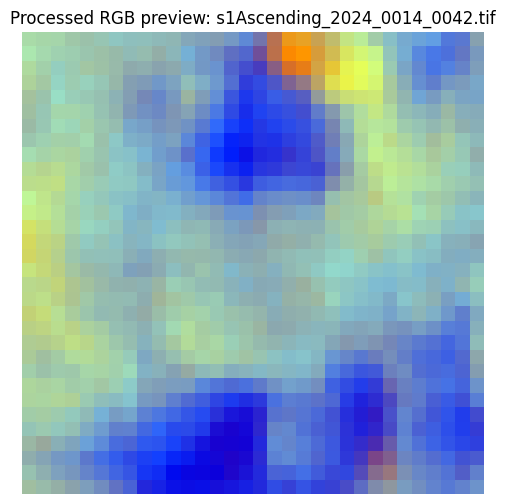


PROCESSED FILE: DEMindices_2024_0002_0000.tif
LOCATION: /content/EO_inference_folder/DEMindices_2024_0002_0000.tif
BANDS: 2
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4796519291267032
      std:  0.19048165212815799

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.48649855614576154
      std:  0.15034779303944007


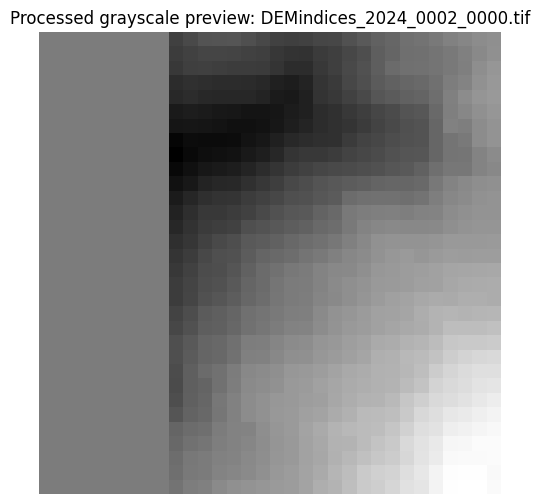


PROCESSED FILE: S2Composite_2024_0023_0012.tif
LOCATION: /content/EO_inference_folder/S2Composite_2024_0023_0012.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 20.0 x 20.0 (approx meters)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.17884150996178505
      std:  0.08197901281236292

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.08794082478380005
      std:  0.07736221489819839

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.0896465853483619
      std:  0.074001612766566

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.36289817152692194
      std:  0.1867145463622156

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4016522478777915
      std:  0.12654118833956995

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.24158274423689363
      std:  0.12399302996482718


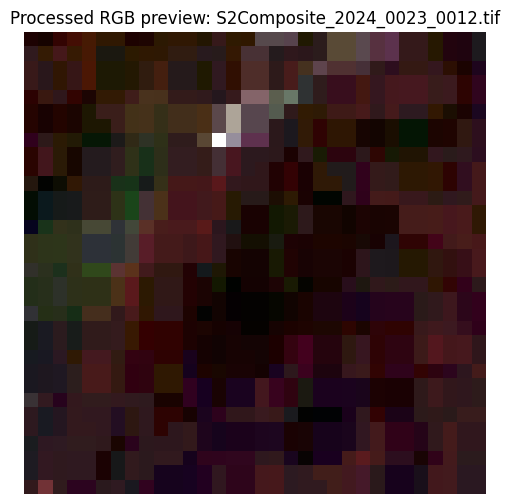


PROCESSED FILE: s1Ascending_2024_0023_0016.tif
LOCATION: /content/EO_inference_folder/s1Ascending_2024_0023_0016.tif
BANDS: 4
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 10.0 x 10.0 (approx meters)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.38254261703514203
      std:  0.17931692520549047

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.44341560381508316
      std:  0.18786511378439355

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6019596612241003
      std:  0.14400751372821957

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6264305318909464
      std:  0.14132845032327004


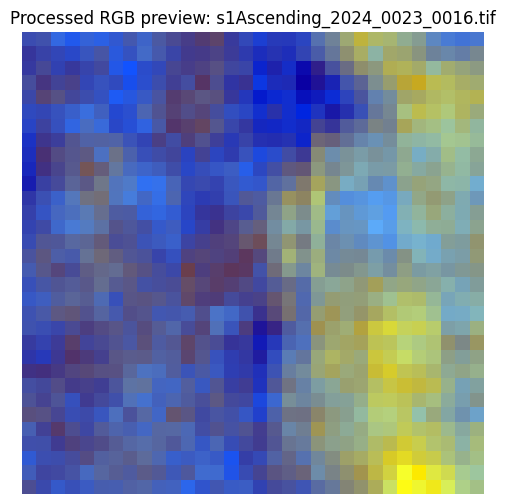


PROCESSED FILE: HLS_2024_0005_0009.tif
LOCATION: /content/EO_inference_folder/HLS_2024_0005_0009.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.82034775899956
      std:  0.09413349260466894

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.14711494424409466
      std:  0.07194171829931785

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.14089910139136919
      std:  0.05854418711741858

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7184189836116275
      std:  0.1246071909839675

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6832540263712872
      std:  0.13168762496041422

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.31674597089113377
      std:  0.13168762467008716

  Band 7 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6586079701919516
      std:  

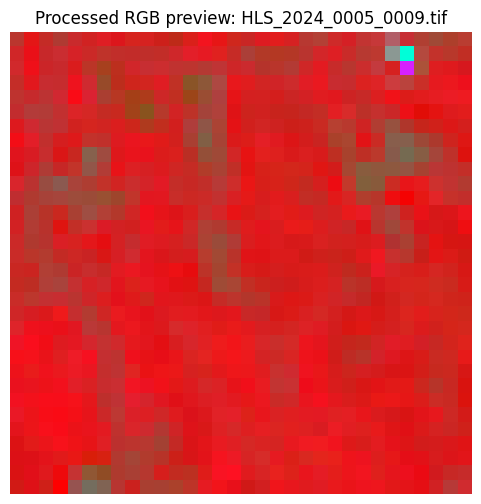

In [195]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (approx meters)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)

            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


## Inference Pipeline

In [199]:
# ----------------------------
# Stage 3: Robust grouped inference + reconstruction
# ----------------------------
import os, re, math
import numpy as np
import rasterio
from glob import glob
from tqdm import tqdm
from scipy import ndimage
import torch

# ---------- CONFIG (adjust if different) ----------
PATCH_SIZE = 32              # patch pixels (per patch file)
OVERLAP = 0.25               # 25% overlap used during patch creation
REFERENCE_RASTER = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/2024_Imagery_For_Inference/s1Ascending_2024.tif"
PATCH_FOLDER = "/content/EO_inference_folder"
OUT_TIF = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction.tif"

# EO lists / spatial resolution (must match your stage1 config)
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
SPATIAL_RES = {
    's1': 10, 's2': 20, 's2idx': 20,
    'landsat': 30, 'landsatidx': 30,
    'hls': 30, 'tcap': 30, 'dem': 30
}

# regex to parse filenames: EO_YYYY_ROW_COL.tif (row/col zero-padded)
FNAME_RE = re.compile(r"(?P<eo>[^_]+)_(?P<yr>\d{4})_(?P<row>\d{4})_(?P<col>\d{4})\.tif$")

# ---------- Read reference raster metadata ----------
with rasterio.open(REFERENCE_RASTER) as src:
    ref_meta = src.meta.copy()
    ref_h, ref_w = src.height, src.width
    ref_transform = src.transform
    ref_crs = src.crs

# ---------- Precompute native stride (in native pixels) ----------
native_stride = int(round(PATCH_SIZE * (1.0 - OVERLAP)))  # e.g., 24 for 25% overlap

# ---------- Scan patch files and map to reference start coords ----------
patch_files = glob(os.path.join(PATCH_FOLDER, "*.tif"))
if len(patch_files) == 0:
    raise RuntimeError(f"No patch files found in {PATCH_FOLDER}")

# dict mapping (ref_row, ref_col) -> { eo_key: filepath, ... }
groups = {}

for p in patch_files:
    fname = os.path.basename(p)
    m = FNAME_RE.match(fname)
    if not m:
        print("Skipping file (unexpected name):", fname)
        continue
    eo_prefix = m.group("eo")
    row_idx = int(m.group("row"))
    col_idx = int(m.group("col"))

    # map eo_prefix to eo_key using your eo_map
    if eo_prefix not in eo_map:
        print("Unknown EO prefix (skipping):", eo_prefix)
        continue
    eo_key = eo_map[eo_prefix]

    # compute reference start pixel: convert this patch's native index to reference 10m grid
    # native stride in native pixels -> in meters = native_stride * SPATIAL_RES[eo_key]
    # convert to reference pixels (10m) => multiply by (SPATIAL_RES / 10)
    meters_per_native_stride = native_stride * SPATIAL_RES[eo_key]
    ref_stride_pixels = int(round(meters_per_native_stride / 10.0))

    ref_start_row = int(round(row_idx * ref_stride_pixels))
    ref_start_col = int(round(col_idx * ref_stride_pixels))

    key = (ref_start_row, ref_start_col)
    groups.setdefault(key, {})[eo_key] = p

# report
print(f"Grouping patches by reference start coordinate ...")
print("Total unique group locations:", len(groups))

# ---------- Prepare accumulation arrays at reference (10m) grid ----------
pred_sum = np.zeros((ref_h, ref_w), dtype=np.float64)
pred_count = np.zeros((ref_h, ref_w), dtype=np.uint16)

# ---------- Helper: read patch into tensor and compute embedding ----------
def read_patch_as_tensor(fp, device):
    # returns tensor shape [1, C, H, W] on device
    with rasterio.open(fp) as src:
        arr = src.read().astype(np.float32)  # [C,H,W]
    # convert to torch tensor
    t = torch.from_numpy(arr).unsqueeze(0).to(device)  # [1,C,H,W]
    return t

# ---------- Loop groups, compute embeddings per EO_list order, run fusion ----------
print("Computing embeddings for all patch groups and running fusion inference ...")
device = next(fusion_model.parameters()).device if hasattr(fusion_model, 'parameters') else ("cuda" if torch.cuda.is_available() else "cpu")

# We will cache embeddings per-file to avoid re-reading if same file used multiple times (shouldn't happen often)
emb_cache = {}

for (ref_r, ref_c), eo_files in tqdm(groups.items(), total=len(groups)):

    # Build token list in order EO_LIST. For missing modalities, insert zero embedding.
    tokens = []
    for eo in EO_LIST:
        if eo in eo_files:
            fp = eo_files[eo]
            if fp in emb_cache:
                emb = emb_cache[fp]
            else:
                try:
                    pt = read_patch_as_tensor(fp, device)  # [1,C,H,W]
                    with torch.no_grad():
                        emb = encoders[eo](pt)           # expected [1, embed_dim]
                    emb_cache[fp] = emb.cpu() if emb.device != torch.device('cpu') else emb
                    emb = emb_cache[fp]
                except Exception as e:
                    # if encoder fails, replace with zero embedding and warn
                    print(f"Warning: failed to embed {fp}: {e}")
                    emb = torch.zeros(1, 128)
                    emb_cache[fp] = emb
            # ensure shape [embed_dim] on cpu numpy later
            tokens.append(emb.squeeze(0).to(device))
        else:
            # missing modality -> zero embedding (matching embedding dim 128)
            tokens.append(torch.zeros(128, device=device))

    # Stack tokens -> shape [N_tokens, embed_dim], then add batch dim -> [1, N_tokens, embed_dim]
    tokens_stack = torch.stack(tokens, dim=0).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        pred_tensor = fusion_model(tokens_stack)  # shape [1] or [1,]
    pred_value = float(pred_tensor.cpu().item())

    # Clip negatives (RH cannot be negative)
    if pred_value < 0:
        pred_value = 0.0

    # Determine coverage area in reference pixels.
    # Use the maximum native patch footprint among modalities present to cover the area reasonably.
    # For each eo in group, compute its patch footprint in reference pixels; take max to be safe.
    max_h = 0
    max_w = 0
    for eo, fp in eo_files.items():
        # patch footprint in meters = PATCH_SIZE * spatial_res[eo]
        meters = PATCH_SIZE * SPATIAL_RES[eo]
        pixels_ref = int(round(meters / 10.0))
        if pixels_ref > max_h:
            max_h = pixels_ref
        if pixels_ref > max_w:
            max_w = pixels_ref

    # fallback to reference patch size for s1 if none found
    if max_h == 0:
        max_h = int(round(PATCH_SIZE * SPATIAL_RES['s1'] / 10.0))
        max_w = max_h

    # compute pixel window to add prediction
    y0 = ref_r
    x0 = ref_c
    y1 = min(ref_h, y0 + max_h)
    x1 = min(ref_w, x0 + max_w)

    if y0 >= ref_h or x0 >= ref_w:
        # patch lies outside target raster (rare) --> skip
        continue

    # Add pred_value into accumulation arrays (sum & count) for averaging overlaps
    pred_sum[y0:y1, x0:x1] += pred_value
    pred_count[y0:y1, x0:x1] += 1

# ---------- Average overlapping contributions ----------
print("Averaging overlapping contributions ...")
valid_mask = pred_count > 0
pred_final = np.full((ref_h, ref_w), np.nan, dtype=np.float32)
pred_final[valid_mask] = (pred_sum[valid_mask] / pred_count[valid_mask]).astype(np.float32)

# ---------- Fill holes (NaNs) using nearest-neighbor via distance transform ----------
print("Filling holes with nearest-neighbor interpolation ...")
nan_mask = np.isnan(pred_final)
if np.any(nan_mask):
    # mask of valid pixels
    valid = ~nan_mask
    # compute nearest valid indices for each pixel
    # distance_transform_edt returns indices for the nearest non-zero elements of input
    # We pass valid as boolean, but distance_transform expects inverted mask; use ~valid (zeros where valid)
    # return_indices=True returns an array of indices; cast to int to avoid IndexError
    _, inds = ndimage.distance_transform_edt(nan_mask, return_distances=True, return_indices=True)
    # inds has shape (ndim, H, W)
    inds = inds.astype(int)
    yi = inds[0]
    xi = inds[1]
    # map
    filled = pred_final[yi, xi]
    pred_final[nan_mask] = filled[nan_mask]

# ---------- Save georeferenced raster ----------
os.makedirs(os.path.dirname(OUT_TIF), exist_ok=True)
out_meta = ref_meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": ref_h,
    "width": ref_w,
    "count": 1,
    "dtype": "float32",
    "crs": ref_crs,
    "transform": ref_transform
})

with rasterio.open(OUT_TIF, "w", **out_meta) as dst:
    dst.write(pred_final, 1)

print("✅ Stage 3 RH raster saved:", OUT_TIF)


Grouping patches by reference start coordinate ...
Total unique group locations: 2756
Computing embeddings for all patch groups and running fusion inference ...


100%|██████████| 2756/2756 [01:41<00:00, 27.24it/s]


Averaging overlapping contributions ...
Filling holes with nearest-neighbor interpolation ...
✅ Stage 3 RH raster saved: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction.tif


Raster info:
Width: 1268, Height: 1256, Bands: 1
CRS: EPSG:32616


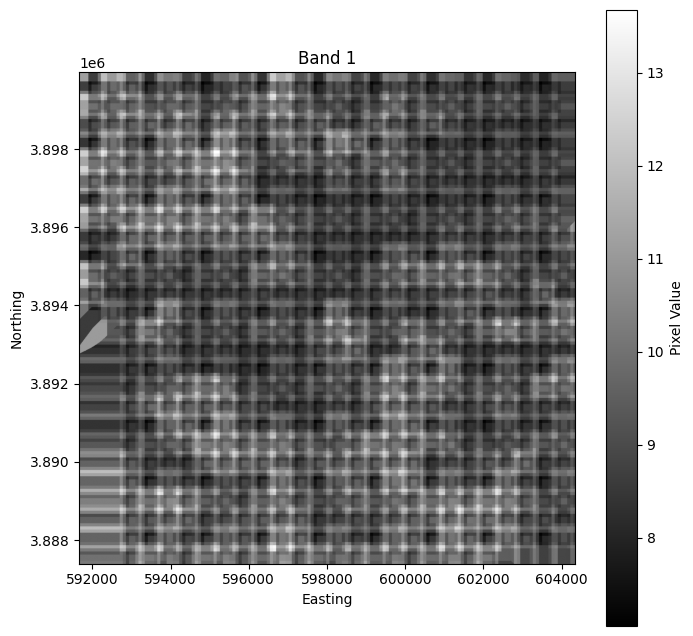

In [200]:
import rasterio
import matplotlib.pyplot as plt

# Path to your raster
ref_raster_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/Stage_3_Inference/Stage3_RH_prediction.tif"

# Open the raster
with rasterio.open(ref_raster_path) as src:
    print("Raster info:")
    print(f"Width: {src.width}, Height: {src.height}, Bands: {src.count}")
    print(f"CRS: {src.crs}")

    # Read the first band
    band1 = src.read(1)

    # Optional: get extent for proper axis labeling
    extent = [
        src.bounds.left, src.bounds.right,
        src.bounds.bottom, src.bounds.top
    ]

# Plot the first band
plt.figure(figsize=(8,8))
plt.imshow(band1, cmap='gray', extent=extent)
plt.title("Band 1")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.colorbar(label="Pixel Value")
plt.show()
